<a href="https://colab.research.google.com/github/saayeen/Clasificaci-n_-Emociones_en_Capturas_de_Videojuegos/blob/main/proyecto_ML_CON_MODELO_PREENTRENADO.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
from google.colab import drive
import os
import shutil
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import random
from PIL import Image
import cv2

import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
# modelo pre entrenado resnet50v2
from tensorflow.keras.applications import ResNet50V2
from tensorflow.keras.applications.resnet_v2 import preprocess_input

from sklearn.metrics import confusion_matrix, classification_report


In [ ]:
# verificar estructura
def check_folder_structure(base_path):
    base_path = Path(base_path)

    print("ESTRUCTURA ACTUAL")
    print("=" * 30)
    for item in base_path.iterdir():
        if item.is_dir():
            print(f" {item.name}")
            images = list(item.glob('*.jpg')) + list(item.glob('*.png')) + list(item.glob('*.jpeg'))
            print(f"   └── {len(images)} imágenes")
        else:
            print(f" {item.name}")

drive_path = '/content/drive/MyDrive/electivo/games_mood'
check_folder_structure(drive_path)

ESTRUCTURA ACTUAL
 happiness
   └── 200 imágenes
 fear
   └── 200 imágenes
 serenity
   └── 200 imágenes
 sadness
   └── 200 imágenes
 anger
   └── 200 imágenes


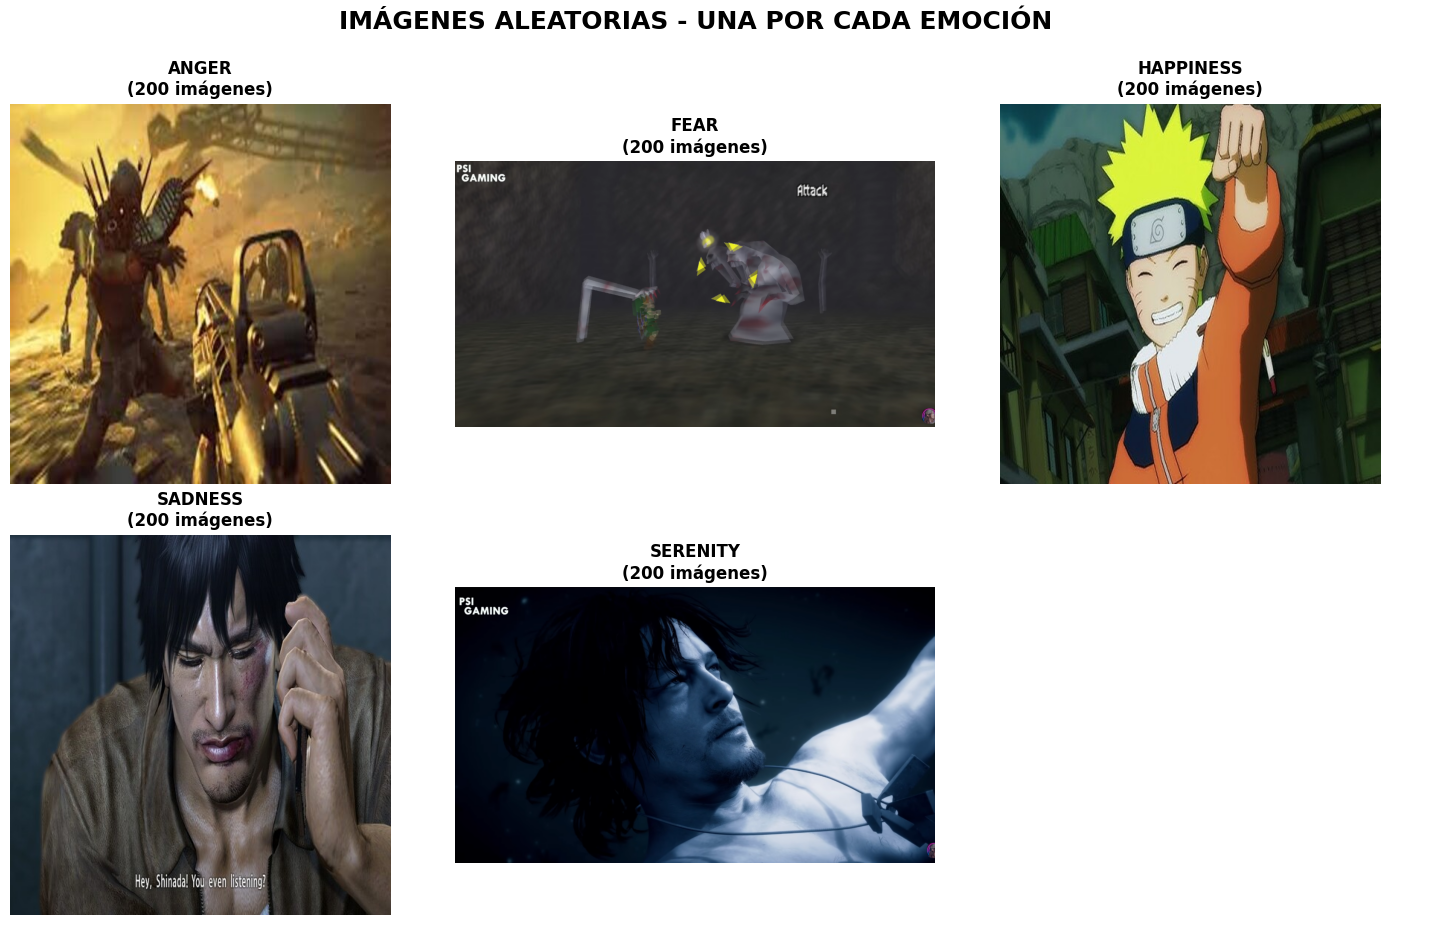

In [ ]:
dataset_path = Path('/content/drive/MyDrive/electivo/games_mood')

# grid de 2x3 (5 emociones + título)
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

emotions = ['anger', 'fear', 'happiness', 'sadness', 'serenity']

for idx, emotion in enumerate(emotions):
    emotion_path = dataset_path / emotion

    if emotion_path.exists():
        images = list(emotion_path.glob('*.*'))

        if images:
            random_image = random.choice(images)

            with Image.open(random_image) as img:
                axes[idx].imshow(img)
                axes[idx].set_title(f"{emotion.upper()}\n({len(images)} imágenes)",
                                   fontsize=12, fontweight='bold')
                axes[idx].axis('off')
        else:
            axes[idx].text(0.5, 0.5, "Sin imágenes",
                          ha='center', va='center', fontsize=10)
            axes[idx].set_title(f"{emotion.upper()} (0)", fontsize=10)
            axes[idx].axis('off')
    else:
        axes[idx].text(0.5, 0.5, "No existe",
                      ha='center', va='center', fontsize=10)
        axes[idx].set_title(f"{emotion.upper()}", fontsize=10)
        axes[idx].axis('off')

axes[5].axis('off')F

plt.suptitle('IMÁGENES ALEATORIAS - UNA POR CADA EMOCIÓN',
             fontsize=18, fontweight='bold', y=0.95)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

In [ ]:
#generadores para imágenes 512x512 adaptados a ResNet50V2
def create_512_generators(dataset_path, batch_size=8):
    print(" CONFIGURANDO GENERADORES 512x512 PARA RESNET")
    print("=" * 60)

    # Data augmentation para entrenamiento
    train_datagen = ImageDataGenerator(
        preprocessing_function=preprocess_input,
        validation_split=0.2,
        rotation_range=15,
        width_shift_range=0.1,
        height_shift_range=0.1,
        horizontal_flip=True,
        zoom_range=0.1,
        brightness_range=[0.9, 1.1],
        fill_mode='nearest'
    )

    val_datagen = ImageDataGenerator(
        preprocessing_function=preprocess_input,
        validation_split=0.2
    )

    train_generator = train_datagen.flow_from_directory(
        dataset_path,
        target_size=(512, 512),
        batch_size=batch_size,
        class_mode='categorical',
        subset='training',
        shuffle=True,
        seed=42
    )

    val_generator = val_datagen.flow_from_directory(
        dataset_path,
        target_size=(512, 512),
        batch_size=batch_size,
        class_mode='categorical',
        subset='validation',
        shuffle=False,
        seed=42
    )

    print("\n GENERADORES 512x512 CONFIGURADOS:")
    print(f"   Clases: {list(train_generator.class_indices.keys())}")
    print(f"   Imágenes entrenamiento: {train_generator.samples}")
    print(f"   Imágenes validación: {val_generator.samples}")
    print(f"   Batch size: {batch_size}")

    return train_generator, val_generator

# crear generadores
train_gen, val_gen = create_512_generators(dataset_path, batch_size=8)

 CONFIGURANDO GENERADORES 512x512 PARA RESNET
Found 800 images belonging to 5 classes.
Found 200 images belonging to 5 classes.

 GENERADORES 512x512 CONFIGURADOS:
   Clases: ['anger', 'fear', 'happiness', 'sadness', 'serenity']
   Imágenes entrenamiento: 800
   Imágenes validación: 200
   Batch size: 8


In [ ]:
# esta función define la arquitectura del modelo basado en ResNet50V2
def create_512_cnn_model():
    print("=" * 60)

    # se carga el modelo base (experto)
    base_model = ResNet50V2(
        weights='imagenet',
        include_top=False,
        input_shape=(512, 512, 3)
    )

    # se congela el conocimiento previo
    base_model.trainable = False

    # se añade las capas finales para las 5 emociones
    model = models.Sequential([
        base_model,
        layers.GlobalAveragePooling2D(),
        layers.Dense(512, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.5),
        layers.Dense(256, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.4),
        layers.Dense(5, activation='softmax')
    ])

    # se compila con una tasa de aprendizaje baja para mayor precisión
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    return model

-- ENTRENAMIENTO CON RESNET50V2 (PRE-ENTRENADO) --

Cargando arquitectura ResNet50V2...

94668760/94668760 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step

Iniciando entrenamiento...

Epoch 1/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.2044 - loss: 2.4211
Epoch 1: val_accuracy improved from None to 0.46500, saving model to best_resnet_model.h5



Epoch 1: finished saving model to best_resnet_model.h5
100/100 ━━━━━━━━━━━━━━━━━━━━ 480s 5s/step - accuracy: 0.2738 - loss: 2.2291 - val_accuracy: 0.4650 - val_loss: 1.3422 - learning_rate: 1.0000e-04
Epoch 2/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 665ms/step - accuracy: 0.4221 - loss: 1.5858
Epoch 2: val_accuracy improved from 0.46500 to 0.53500, saving model to best_resnet_model.h5



Epoch 2: finished saving model to best_resnet_model.h5
100/100 ━━━━━━━━━━━━━━━━━━━━ 71s 707ms/step - accuracy: 0.4150 - loss: 1.7034 - val_accuracy: 0.5350 - val_loss: 1.1773 - learning_rate: 1.0000e-04
Epoch 3/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 672ms/step - accuracy: 0.4782 - loss: 1.5641
Epoch 3: val_accuracy improved from 0.53500 to 0.56000, saving model to best_resnet_model.h5



Epoch 3: finished saving model to best_resnet_model.h5
100/100 ━━━━━━━━━━━━━━━━━━━━ 71s 715ms/step - accuracy: 0.4638 - loss: 1.5638 - val_accuracy: 0.5600 - val_loss: 1.1537 - learning_rate: 1.0000e-04
Epoch 4/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 668ms/step - accuracy: 0.4576 - loss: 1.5137
Epoch 4: val_accuracy improved from 0.56000 to 0.58000, saving model to best_resnet_model.h5



Epoch 4: finished saving model to best_resnet_model.h5
100/100 ━━━━━━━━━━━━━━━━━━━━ 71s 708ms/step - accuracy: 0.4800 - loss: 1.4901 - val_accuracy: 0.5800 - val_loss: 1.1151 - learning_rate: 1.0000e-04
Epoch 5/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 662ms/step - accuracy: 0.5181 - loss: 1.4675
Epoch 5: val_accuracy did not improve from 0.58000
100/100 ━━━━━━━━━━━━━━━━━━━━ 70s 697ms/step - accuracy: 0.5288 - loss: 1.4532 - val_accuracy: 0.5800 - val_loss: 1.1697 - learning_rate: 1.0000e-04
Epoch 6/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 663ms/step - accuracy: 0.5371 - loss: 1.2782
Epoch 6: val_accuracy did not improve from 0.58000
100/100 ━━━━━━━━━━━━━━━━━━━━ 70s 699ms/step - accuracy: 0.5250 - loss: 1.3446 - val_accuracy: 0.5800 - val_loss: 1.1668 - learning_rate: 1.0000e-04
Epoch 7/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 668ms/step - accuracy: 0.6050 - loss: 1.1580
Epoch 7: val_accuracy improved from 0.58000 to 0.59500, saving model to best_resnet_model.h5



Epoch 7: finished saving model to best_resnet_model.h5
100/100 ━━━━━━━━━━━━━━━━━━━━ 71s 709ms/step - accuracy: 0.5750 - loss: 1.1877 - val_accuracy: 0.5950 - val_loss: 1.1612 - learning_rate: 1.0000e-04
Epoch 8/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 669ms/step - accuracy: 0.5928 - loss: 1.1357
Epoch 8: val_accuracy improved from 0.59500 to 0.61500, saving model to best_resnet_model.h5



Epoch 8: finished saving model to best_resnet_model.h5
100/100 ━━━━━━━━━━━━━━━━━━━━ 71s 710ms/step - accuracy: 0.5775 - loss: 1.2138 - val_accuracy: 0.6150 - val_loss: 1.1750 - learning_rate: 1.0000e-04
Epoch 9/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 664ms/step - accuracy: 0.6116 - loss: 1.1849
Epoch 9: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-05.

Epoch 9: val_accuracy did not improve from 0.61500
100/100 ━━━━━━━━━━━━━━━━━━━━ 70s 699ms/step - accuracy: 0.5825 - loss: 1.2375 - val_accuracy: 0.5950 - val_loss: 1.1929 - learning_rate: 1.0000e-04
Epoch 10/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 679ms/step - accuracy: 0.6006 - loss: 1.1427
Epoch 10: val_accuracy did not improve from 0.61500
100/100 ━━━━━━━━━━━━━━━━━━━━ 71s 714ms/step - accuracy: 0.5962 - loss: 1.1427 - val_accuracy: 0.5950 - val_loss: 1.1692 - learning_rate: 5.0000e-05
Restoring model weights from the end of the best epoch: 4.

-- Entrenamiento completado!


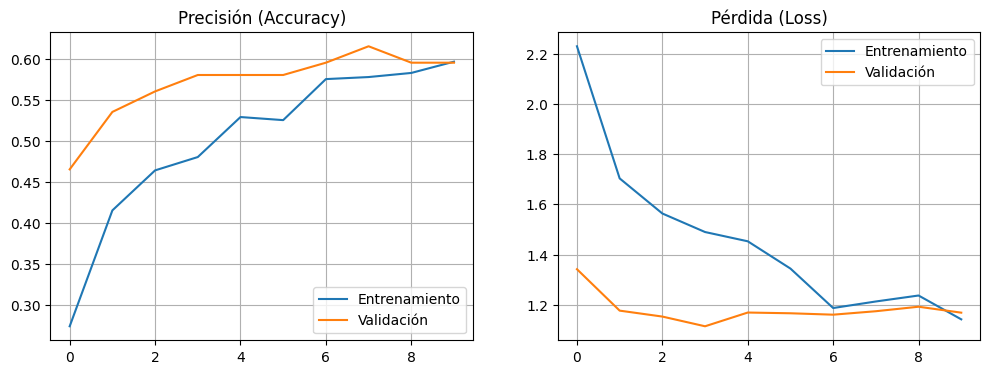

In [ ]:
print("="*60)
print("-- ENTRENAMIENTO CON RESNET50V2 (PRE-ENTRENADO) --")
print("="*60)

# crea el modelo usando la función de ResNet
print("\nCargando arquitectura ResNet50V2...\n")
model_new = create_512_cnn_model()

# configuración de Callbacks
callbacks = [
    EarlyStopping(
        monitor='val_loss',
        patience=10,
        restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=5,
        min_lr=1e-6,
        verbose=1
    ),
    ModelCheckpoint(
        'best_resnet_model.h5',
        monitor='val_accuracy',
        save_best_only=True,
        verbose=1
    )
]

# entrenamiento
print("\nIniciando entrenamiento...\n")
train_gen.reset()
val_gen.reset()

try:
    history = model_new.fit(
        train_gen,
        validation_data=val_gen,
        epochs=10,
        callbacks=callbacks,
        verbose=1
    )

    print("\n-- Entrenamiento completado!")

    # gráficos de resultados
    plt.figure(figsize=(12, 4))
    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'], label='Entrenamiento')
    plt.plot(history.history['val_accuracy'], label='Validación')
    plt.title('Precisión (Accuracy)')
    plt.legend()
    plt.grid(True)

    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'], label='Entrenamiento')
    plt.plot(history.history['val_loss'], label='Validación')
    plt.title('Pérdida (Loss)')
    plt.legend()
    plt.grid(True)
    plt.show()

except Exception as e:
    print(f"\n ERROR: {e}")


---- CONTINUANDO ENTRENAMIENTO COMPLETO (RESNET) ------
Epoch 11/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 700ms/step - accuracy: 0.4870 - loss: 1.5775
Epoch 11: val_accuracy improved from None to 0.60000, saving model to final_resnet_model.h5



Epoch 11: finished saving model to final_resnet_model.h5
100/100 ━━━━━━━━━━━━━━━━━━━━ 75s 747ms/step - accuracy: 0.5113 - loss: 1.4772 - val_accuracy: 0.6000 - val_loss: 1.1507 - learning_rate: 5.0000e-05
Epoch 12/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 685ms/step - accuracy: 0.5320 - loss: 1.4009
Epoch 12: val_accuracy improved from 0.60000 to 0.60500, saving model to final_resnet_model.h5



Epoch 12: finished saving model to final_resnet_model.h5
100/100 ━━━━━━━━━━━━━━━━━━━━ 73s 725ms/step - accuracy: 0.5450 - loss: 1.3772 - val_accuracy: 0.6050 - val_loss: 1.1603 - learning_rate: 5.0000e-05
Epoch 13/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 688ms/step - accuracy: 0.5534 - loss: 1.3264
Epoch 13: val_accuracy did not improve from 0.60500
100/100 ━━━━━━━━━━━━━━━━━━━━ 72s 725ms/step - accuracy: 0.5387 - loss: 1.3775 - val_accuracy: 0.5850 - val_loss: 1.1597 - learning_rate: 5.0000e-05
Epoch 14/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 686ms/step - accuracy: 0.5612 - loss: 1.2167
Epoch 14: val_accuracy did not improve from 0.60500
100/100 ━━━━━━━━━━━━━━━━━━━━ 72s 720ms/step - accuracy: 0.5625 - loss: 1.2514 - val_accuracy: 0.5700 - val_loss: 1.1691 - learning_rate: 5.0000e-05
Epoch 15/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 677ms/step - accuracy: 0.6168 - loss: 1.0796
Epoch 15: val_accuracy did not improve from 0.60500
100/100 ━━━━━━━━━━━━━━━━━━━━ 71s 713ms/step - accuracy: 0.6050 - loss: 1.17

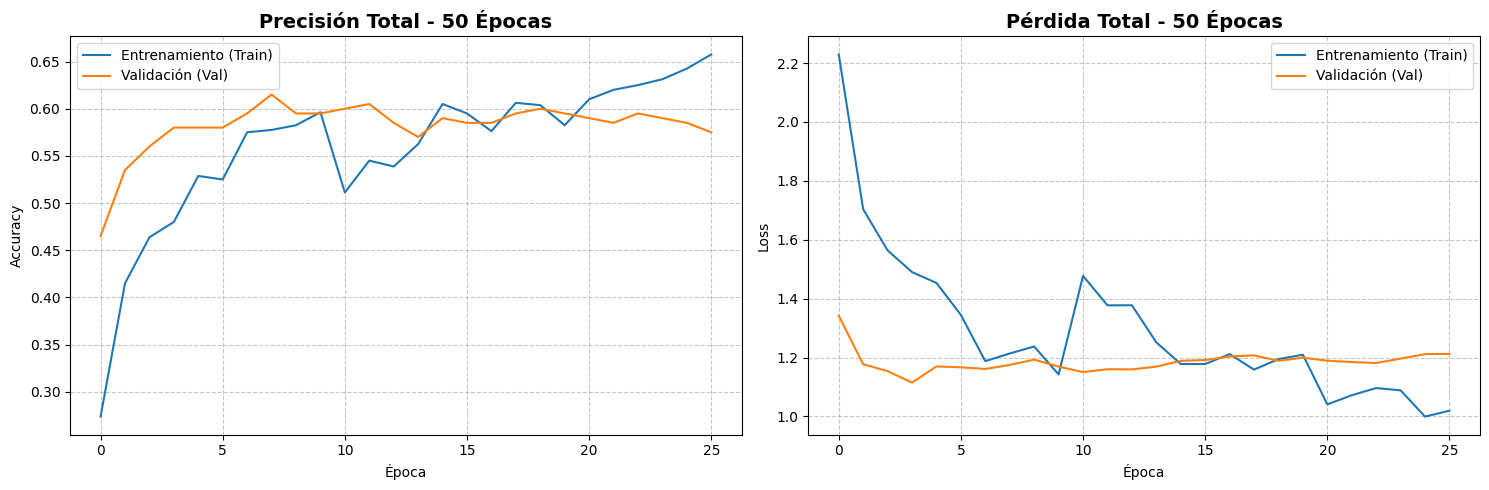

In [ ]:
if 'history' in locals() and history.history['val_accuracy'][-1] > 0.25:
    print("\n" + "="*60)
    print("---- CONTINUANDO ENTRENAMIENTO COMPLETO (RESNET) ------")
    print("="*60)

    # se entrena desde donde quedó (epoch 10) hasta la 50
    history_full = model_new.fit(
        train_gen,
        validation_data=val_gen,
        initial_epoch=len(history.history['loss']),
        epochs=50,
        callbacks=[
            EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True, verbose=1),
            ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=7, min_lr=1e-6, verbose=1),
            ModelCheckpoint('final_resnet_model.h5', monitor='val_accuracy', save_best_only=True, verbose=1)
        ],
        verbose=1
    )

    for key in history.history.keys():
        history.history[key].extend(history_full.history[key])

    plt.figure(figsize=(15, 5))

    # gráfico de precisión
    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'], label='Entrenamiento (Train)')
    plt.plot(history.history['val_accuracy'], label='Validación (Val)')
    plt.title('Precisión Total - 50 Épocas', fontsize=14, fontweight='bold')
    plt.xlabel('Época')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.7)

    # gráfico de pérdida
    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'], label='Entrenamiento (Train)')
    plt.plot(history.history['val_loss'], label='Validación (Val)')
    plt.title('Pérdida Total - 50 Épocas', fontsize=14, fontweight='bold')
    plt.xlabel('Época')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.7)

    plt.tight_layout()
    plt.show()

    model_new.save('/content/drive/MyDrive/electivo/modelo_emociones_final.h5')

else:
    print("\nEl entrenamiento inicial no fue suficiente para continuar.")

In [ ]:
def test_model_thoroughly(model, test_gen, class_names):
    # prueba exhaustiva del modelo
    print("\n" + "="*60)
    print("---- PRUEBA EXHAUSTIVA DEL MODELO ----")
    print("="*60)

    test_gen.reset()
    loss, accuracy = model.evaluate(test_gen, verbose=0)
    print(f"- Val Loss: {loss:.4f}")
    print(f"- Val Accuracy: {accuracy:.4f} ({accuracy*100:.1f}%)")

    test_gen.reset()
    predictions = model.predict(test_gen, verbose=1)
    predicted_classes = np.argmax(predictions, axis=1)
    true_classes = test_gen.classes

    print("\nDISTRIBUCIÓN DE PREDICCIONES:")
    unique, counts = np.unique(predicted_classes, return_counts=True)
    total = len(predicted_classes)
    for cls, count in zip(unique, counts):
        percentage = count/total*100
        print(f"  {class_names[cls]}: {count}/{total} ({percentage:.1f}%)")

    most_common = np.bincount(predicted_classes).argmax()
    most_common_count = np.bincount(predicted_classes).max()
    most_common_percentage = most_common_count/total*100

    print(f"  -- Clase más común: {class_names[most_common]} ({most_common_percentage:.1f}%)")

    if most_common_percentage > 80:
        print(f"  -- El modelo tiene un sesgo hacia {class_names[most_common]}")

    return accuracy, predicted_classes, true_classes

if 'model_new' in locals() and 'val_gen' in locals():
    class_names = list(val_gen.class_indices.keys())
    print(f"Clases detectadas: {class_names}")

    accuracy, preds, trues = test_model_thoroughly(model_new, val_gen, class_names)

    if accuracy > 0.20:
        model_new.save('/content/final_trained_model.h5')
        print(f"\nModelo verificado y guardado localmente.")
        print(f"   Accuracy final en validación: {accuracy*100:.1f}%")
else:
    print("ERROR: 'model_new' o 'val_gen' no están definidos.")

Clases detectadas: ['anger', 'fear', 'happiness', 'sadness', 'serenity']

---- PRUEBA EXHAUSTIVA DEL MODELO ----
- Val Loss: 1.1507
- Val Accuracy: 0.6000 (60.0%)
25/25 ━━━━━━━━━━━━━━━━━━━━ 7s 137ms/step



DISTRIBUCIÓN DE PREDICCIONES:
  anger: 40/200 (20.0%)
  fear: 46/200 (23.0%)
  happiness: 24/200 (12.0%)
  sadness: 27/200 (13.5%)
  serenity: 63/200 (31.5%)
  -- Clase más común: serenity (31.5%)

Modelo verificado y guardado localmente.
   Accuracy final en validación: 60.0%


In [ ]:
def predict_emotion_final(img_path):
    # función auxiliar para procesar y predecir una imagen
    img = Image.open(img_path).convert('RGB')
    img = img.resize((512, 512))
    img_array = np.array(img)

    # preprocesar para ResNet
    img_array = preprocess_input(img_array)
    img_array = np.expand_dims(img_array, axis=0)

    # predecir usando el modelo entrenado
    predictions = model_new.predict(img_array, verbose=0)
    class_names = ['anger', 'fear', 'happiness', 'sadness', 'serenity']

    predicted_idx = np.argmax(predictions[0])
    return class_names[predicted_idx], predictions[0][predicted_idx]

print("Función de predicción lista para usar con model_new.")

Función de predicción lista para usar con model_new.


In [ ]:
def dibujar_prediccion_cv2(img_path, pred, conf):
    img = cv2.imread(str(img_path))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    texto = f"{pred.upper()} ({conf:.1%})"

    # para que el texto se lea mejor
    cv2.rectangle(img, (10, 10), (400, 60), (0, 0, 0), -1)
    cv2.putText(img, texto, (20, 45), cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 255, 0), 2)
    return img

print("dibujar_prediccion_cv2() lista.")

In [1]:
def run_final_tests():
    print("--- INICIANDO TEST FINAL CON IMÁGENES DEL DRIVE ---")
    class_names = ['anger', 'fear', 'happiness', 'sadness', 'serenity']

    # prueba una imagen aleatoria de cada emoción
    fig, axes = plt.subplots(1, 5, figsize=(20, 5))
    for i, emotion in enumerate(class_names):
        folder = Path(drive_path) / emotion
        img_list = list(folder.glob('*.*'))
        if img_list:
            random_img = random.choice(img_list)
            pred, conf = predict_emotion_final(random_img)

            pred, conf = predict_emotion_final(random_img)
            img_con_texto = dibujar_prediccion_cv2(random_img, pred, conf)
            axes[i].imshow(img_con_texto)
            axes[i].set_title(f"REAL: {emotion}", color=('green' if pred==emotion else 'red'))
            axes[i].axis('off')
    plt.show()

    # botón para subir imagen
    print("\n" + "="*50)
    print("SUBIR IMAGEN NUEVA")
    from google.colab import files
    uploaded = files.upload()
    for fn in uploaded.keys():
        pred, conf = predict_emotion_final(fn)
        plt.imshow(Image.open(fn))
        plt.title(f"PREDICCIÓN: {pred.upper()} ({conf:.1%})")
        plt.axis('off')
        plt.show()

run_final_tests()

--- INICIANDO TEST FINAL CON IMÁGENES DEL DRIVE ---


NameError: name 'plt' is not defined

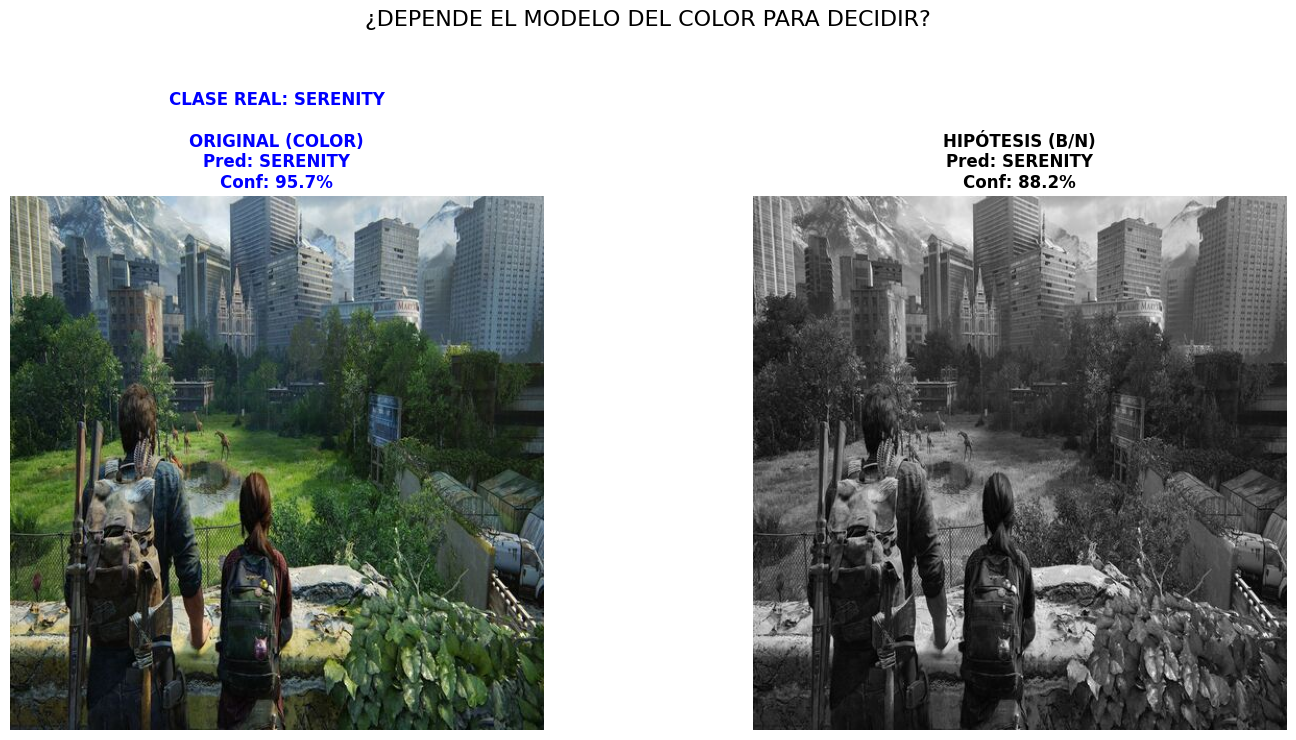


ANÁLISIS DE RESULTADOS PARA: SERENITY
--> El modelo mantuvo la predicción 'serenity'.
--> Esto sugiere que se fija en las FORMAS y ESTRUCTURAS.


In [ ]:
def test_hypothesis_colors(img_path):

    clase_real = Path(img_path).parent.name

    # Carga imagen original
    img_color = Image.open(img_path).convert('RGB')

    # Crea versión en blanco y negro (pero manteniendo 3 canales para el modelo)
    img_array = np.array(img_color)
    gray = cv2.cvtColor(img_array, cv2.COLOR_RGB2GRAY)
    img_bw_array = cv2.merge([gray, gray, gray])
    img_bw = Image.fromarray(img_bw_array)

    # Predicciones
    temp_path = "temp_bw.jpg"
    img_bw.save(temp_path)

    pred_color, conf_color = predict_emotion_final(img_path)
    pred_bw, conf_bw = predict_emotion_final(temp_path)

    # Muestra comparación visual
    fig, axes = plt.subplots(1, 2, figsize=(15, 7))

    axes[0].imshow(img_color)
    axes[0].set_title(f"CLASE REAL: {clase_real.upper()}\n\nORIGINAL (COLOR)\nPred: {pred_color.upper()}\nConf: {conf_color:.1%}",
                      fontsize=12, fontweight='bold', color='blue')
    axes[0].axis('off')

    axes[1].imshow(img_bw)
    axes[1].set_title(f"\n\nHIPÓTESIS (B/N)\nPred: {pred_bw.upper()}\nConf: {conf_bw:.1%}",
                      fontsize=12, fontweight='bold')
    axes[1].axis('off')

    plt.suptitle("¿DEPENDE EL MODELO DEL COLOR PARA DECIDIR?", fontsize=16, y=1.05)
    plt.tight_layout()
    plt.show()

    # Mensaje de análisis
    print(f"\nANÁLISIS DE RESULTADOS PARA: {clase_real.upper()}")
    if pred_color == pred_bw:
        print(f"--> El modelo mantuvo la predicción '{pred_color}'.")
        print(f"--> Esto sugiere que se fija en las FORMAS y ESTRUCTURAS.")
    else:
        print(f"--> La predicción CAMBIÓ de '{pred_color}' a '{pred_bw}'.")
        print(f"--> Esto confirma la hipótesis: el COLOR es clave para su decisión.")

folder_test = Path(drive_path) / 'serenity'  # Aquí se puede cambiar el folder
todas_las_fotos = list(folder_test.glob('*.*'))

if todas_las_fotos:
    foto_aleatoria = random.choice(todas_las_fotos)
    test_hypothesis_colors(foto_aleatoria)
else:
    print(f"No se encontraron fotos en la carpeta: {folder_test}")

In [ ]:
def stress_test_hypothesis(emotion='anger', num_samples=20):
    folder = Path(drive_path) / emotion
    images = list(folder.glob('*.*'))
    samples = random.sample(images, min(num_samples, len(images)))

    matches = 0
    print(f"--- TEST DE ESTRÉS: {emotion.upper()} ---")

    for img_p in samples:
        # predicción color
        pred_c, _ = predict_emotion_final(img_p)

        # predicción B/N
        img_bw = Image.open(img_p).convert('L').convert('RGB')
        img_bw.save('temp_stress.jpg')
        pred_bw, _ = predict_emotion_final('temp_stress.jpg')

        if pred_c == pred_bw:
            matches += 1

    loyalty = (matches / len(samples)) * 100
    print(f"\nRESULTADO FINAL:")
    print(f"De {len(samples)} fotos, el modelo mantuvo su opinión en {matches} tras quitar el color.")
    print(f"Índice de Lealtad a la Forma: {loyalty:.1f}%")
    if loyalty < 50:
        print("--> CONCLUSIÓN: El modelo depende fuertemente del COLOR.")
    else:
        print("--> CONCLUSIÓN: El modelo se basa más en ESTRUCTURAS que en color.")

stress_test_hypothesis('anger')

--- TEST DE ESTRÉS: ANGER ---

RESULTADO FINAL:
De 20 fotos, el modelo mantuvo su opinión en 14 tras quitar el color.
Índice de Lealtad a la Forma: 70.0%
--> CONCLUSIÓN: El modelo se basa más en ESTRUCTURAS que en color.


--- GENERANDO ANÁLISIS ESTADÍSTICO DE ERRORES ---
25/25 ━━━━━━━━━━━━━━━━━━━━ 5s 196ms/step


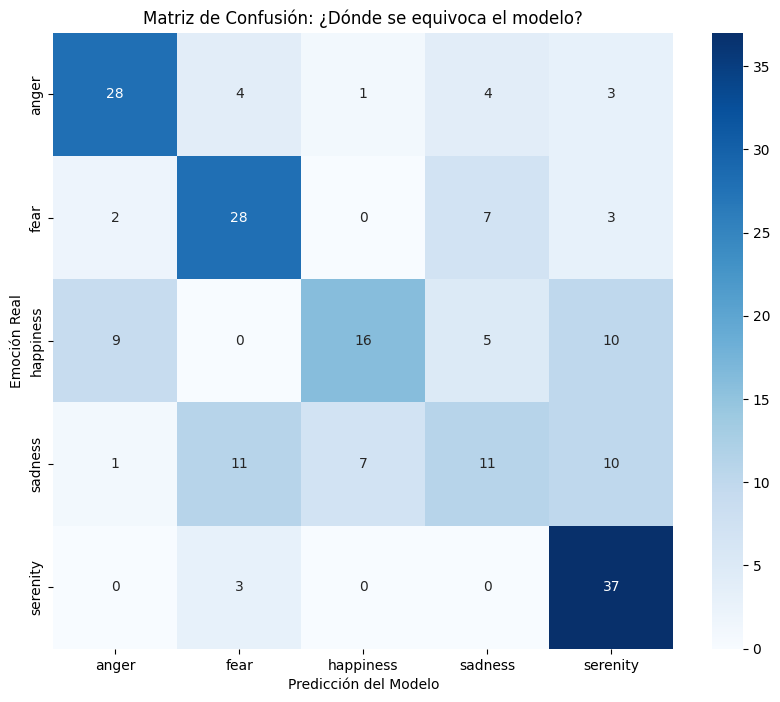


REPORTE DE PRECISIÓN POR EMOCIÓN:
              precision    recall  f1-score   support

       anger       0.70      0.70      0.70        40
        fear       0.61      0.70      0.65        40
   happiness       0.67      0.40      0.50        40
     sadness       0.41      0.28      0.33        40
    serenity       0.59      0.93      0.72        40

    accuracy                           0.60       200
   macro avg       0.59      0.60      0.58       200
weighted avg       0.59      0.60      0.58       200



In [ ]:
def plot_statistical_analysis():
    print("--- GENERANDO ANÁLISIS ESTADÍSTICO DE ERRORES ---")
    val_gen.reset()
    y_true = val_gen.classes
    preds = model_new.predict(val_gen)
    y_pred = np.argmax(preds, axis=1)
    class_names = list(val_gen.class_indices.keys())

    cm = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names)
    plt.xlabel('Predicción del Modelo')
    plt.ylabel('Emoción Real')
    plt.title('Matriz de Confusión: ¿Dónde se equivoca el modelo?')
    plt.show()

    print("\nREPORTE DE PRECISIÓN POR EMOCIÓN:")
    print(classification_report(y_true, y_pred, target_names=class_names))

plot_statistical_analysis()

--- ANALIZANDO DEPENDENCIA DEL COLOR (Muestra: 15 fotos por clase) ---


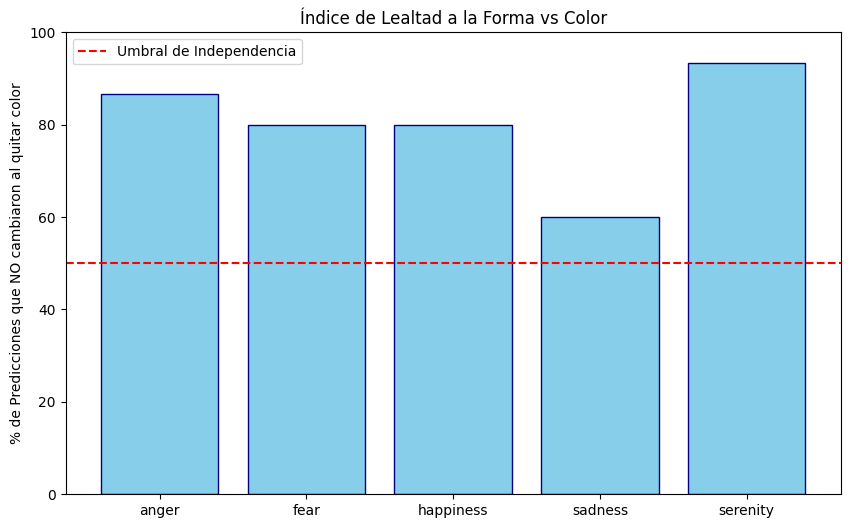

Emoción ANGER: 86.66666666666667% de estabilidad sin color.
Emoción FEAR: 80.0% de estabilidad sin color.
Emoción HAPPINESS: 80.0% de estabilidad sin color.
Emoción SADNESS: 60.0% de estabilidad sin color.
Emoción SERENITY: 93.33333333333333% de estabilidad sin color.


In [ ]:
def statistical_color_test(num_samples_per_class=10):
    class_names = ['anger', 'fear', 'happiness', 'sadness', 'serenity']
    results = {}

    print(f"--- ANALIZANDO DEPENDENCIA DEL COLOR (Muestra: {num_samples_per_class} fotos por clase) ---")

    for emotion in class_names:
        folder = Path(drive_path) / emotion
        images = list(folder.glob('*.*'))
        samples = random.sample(images, min(num_samples_per_class, len(images)))

        matches = 0
        for img_p in samples:
            # predicción Color
            pred_color, _ = predict_emotion_final(img_p)

            # predicción Blanco y Negro
            img_bw = Image.open(img_p).convert('L').convert('RGB')
            img_bw.save('temp_stat.jpg')
            pred_bw, _ = predict_emotion_final('temp_stat.jpg')

            if pred_color == pred_bw:
                matches += 1

        results[emotion] = (matches / len(samples)) * 100

    # Graficar resultados
    plt.figure(figsize=(10, 6))
    plt.bar(results.keys(), results.values(), color='skyblue', edgecolor='navy')
    plt.axhline(y=50, color='r', linestyle='--', label='Umbral de Independencia')
    plt.ylabel('% de Predicciones que NO cambiaron al quitar color')
    plt.title('Índice de Lealtad a la Forma vs Color')
    plt.ylim(0, 100)
    plt.legend()
    plt.show()

    for emotion, value in results.items():
        print(f"Emoción {emotion.upper()}: {value}% de estabilidad sin color.")

statistical_color_test(num_samples_per_class=15)

In [ ]:
def stress_test_hypothesis(emotion='anger', num_samples=20):
    folder = Path(drive_path) / emotion
    images = list(folder.glob('*.*'))
    samples = random.sample(images, min(num_samples, len(images)))

    matches = 0
    print(f"--- TEST DE ESTRÉS: {emotion.upper()} ---")

    for img_p in samples:
        # predicción color
        pred_c, _ = predict_emotion_final(img_p)

        # predicción B/N
        img_bw = Image.open(img_p).convert('L').convert('RGB')
        img_bw.save('temp_stress.jpg')
        pred_bw, _ = predict_emotion_final('temp_stress.jpg')

        if pred_c == pred_bw:
            matches += 1

    loyalty = (matches / len(samples)) * 100
    print(f"\nRESULTADO FINAL:")
    print(f"De {len(samples)} fotos, el modelo mantuvo su opinión en {matches} tras quitar el color.")
    print(f"Índice de Lealtad a la Forma: {loyalty:.1f}%")
    if loyalty < 50:
        print("--> CONCLUSIÓN: El modelo depende fuertemente del COLOR.")
    else:
        print("--> CONCLUSIÓN: El modelo se basa más en ESTRUCTURAS que en color.")

stress_test_hypothesis('anger')

--- TEST DE ESTRÉS: ANGER ---

RESULTADO FINAL:
De 20 fotos, el modelo mantuvo su opinión en 17 tras quitar el color.
Índice de Lealtad a la Forma: 85.0%
--> CONCLUSIÓN: El modelo se basa más en ESTRUCTURAS que en color.


# Mejora v2: Augmentation Orientado (CutOut + Random Resized Crop + Color Jitter HSV)

Entrenamos un nuevo modelo sobre los mismos datos usando técnicas de mezcla de imágenes para que aprenda fronteras más robustas entre clases similares (Anger/Fear, Happiness/Serenity).

In [ ]:
# cutout orientado al objeto
def cutout_orientado(image, hole_size=90, center_bias=0.7):
    img = image.copy()
    h, w = img.shape[:2]

    if np.random.random() < center_bias:
        # parche cerca del centro (zona donde suele estar el sujeto)
        cx = np.random.randint(int(w * 0.3), int(w * 0.7))
        cy = np.random.randint(int(h * 0.25), int(h * 0.75))
    else:
        # parche en cualquier parte (mantiene algo de variedad)
        cx = np.random.randint(0, w)
        cy = np.random.randint(0, h)

    x1 = max(0, cx - hole_size // 2)
    x2 = min(w, cx + hole_size // 2)
    y1 = max(0, cy - hole_size // 2)
    y2 = min(h, cy + hole_size // 2)

    img[y1:y2, x1:x2] = 0
    return img

In [ ]:
# random resized crop
def random_resized_crop(image, target_size=512, scale=(0.7, 1.0)):
    h, w = image.shape[:2]

    # área del recorte (entre 70% y 100% del original)
    area_ratio = np.random.uniform(scale[0], scale[1])
    crop_h = int(h * np.sqrt(area_ratio))
    crop_w = int(w * np.sqrt(area_ratio))

    # posición aleatoria del recorte
    max_y = max(1, h - crop_h)
    max_x = max(1, w - crop_w)
    y1 = np.random.randint(0, max_y)
    x1 = np.random.randint(0, max_x)

    crop = image[y1:y1 + crop_h, x1:x1 + crop_w]

    # reescalar de vuelta al tamaño objetivo
    crop_resized = cv2.resize(crop, (target_size, target_size),
                              interpolation=cv2.INTER_LINEAR)
    return crop_resized

In [ ]:
#color jitter en espacio hsv
def color_jitter_hsv(image, hue_shift=10, sat_range=(0.7, 1.3),
                      val_range=(0.7, 1.3)):
    img = image.astype(np.uint8)
    hsv = cv2.cvtColor(img, cv2.COLOR_RGB2HSV).astype(np.float32)

    # matiz: desplazamiento aleatorio (-hue_shift, +hue_shift)
    hsv[:, :, 0] = (hsv[:, :, 0] + np.random.uniform(-hue_shift, hue_shift)) % 180

    # saturación: multiplicador aleatorio
    hsv[:, :, 1] = np.clip(hsv[:, :, 1] * np.random.uniform(*sat_range), 0, 255)

    # brillo/Valor: multiplicador aleatorio
    hsv[:, :, 2] = np.clip(hsv[:, :, 2] * np.random.uniform(*val_range), 0, 255)

    hsv = hsv.astype(np.uint8)
    return cv2.cvtColor(hsv, cv2.COLOR_HSV2RGB)


def color_jitter_sadness(image):
    img = image.astype(np.uint8)
    hsv = cv2.cvtColor(img, cv2.COLOR_RGB2HSV).astype(np.float32)

    # desplazar matiz hacia el azul/gris (rango ~100-140 en OpenCV HSV)
    hsv[:, :, 0] = np.clip(hsv[:, :, 0] * 0.3 + 110, 0, 179)

    # bajar saturación fuerte (colores más "lavados")
    hsv[:, :, 1] = np.clip(hsv[:, :, 1] * np.random.uniform(0.3, 0.6), 0, 255)

    # bajar brillo (atmósfera más oscura/apagada)
    hsv[:, :, 2] = np.clip(hsv[:, :, 2] * np.random.uniform(0.6, 0.85), 0, 255)

    hsv = hsv.astype(np.uint8)
    return cv2.cvtColor(hsv, cv2.COLOR_HSV2RGB)

In [ ]:
# generar v2
class AugmentedGenerator(tf.keras.utils.Sequence):
    def __init__(self, base_generator, sadness_class_idx=None,
                 cutout_prob=0.4, crop_prob=0.5, jitter_prob=0.5,
                 sadness_jitter_prob=0.7):
        self.gen = base_generator
        self.cutout_prob = cutout_prob
        self.crop_prob = crop_prob
        self.jitter_prob = jitter_prob
        self.sadness_jitter_prob = sadness_jitter_prob

        # detectar automáticamente el índice de la clase 'sadness'
        if sadness_class_idx is None and hasattr(base_generator, 'class_indices'):
            self.sadness_idx = base_generator.class_indices.get('sadness', None)
        else:
            self.sadness_idx = sadness_class_idx

    def __len__(self):
        return len(self.gen)

    def __getitem__(self, idx):
        images, labels = self.gen[idx]
        # las imágenes ya vienen preprocesadas (rango resnet), las
        # devolvemos a [0,255] para aplicar transformaciones de color
        # y luego las volvemos a preprocesar.

        processed = []
        for i in range(len(images)):
            img = images[i]

            # reconstruir aproximación a rango 0-255 desde preprocess_input
            # (resnetV2 usa rango [-1, 1] aprox)
            img_255 = ((img + 1.0) * 127.5).clip(0, 255).astype(np.uint8)

            es_sadness = (self.sadness_idx is not None and
                         np.argmax(labels[i]) == self.sadness_idx)

            # random resized crop
            if np.random.random() < self.crop_prob:
                img_255 = random_resized_crop(img_255, target_size=512)

            # color jitter: reforzado si es sadness, normal si no
            if es_sadness and np.random.random() < self.sadness_jitter_prob:
                img_255 = color_jitter_sadness(img_255)
            elif np.random.random() < self.jitter_prob:
                img_255 = color_jitter_hsv(img_255)

            # cutout orientado al objeto
            if np.random.random() < self.cutout_prob:
                img_255 = cutout_orientado(img_255, hole_size=90, center_bias=0.7)

            # volver a aplicar preprocess_input para que entre igual al modelo
            img_final = preprocess_input(img_255.astype(np.float32))
            processed.append(img_final)

        return np.array(processed), labels

    def on_epoch_end(self):
        self.gen.on_epoch_end()

print("Nuevo generador: CutOut orientado + RandomResizedCrop + ColorJitter HSV")

Nuevo generador: CutOut orientado + RandomResizedCrop + ColorJitter HSV


-- MODELO V2: RESNET50V2 + AUGMENTATION AVANZADO --
Found 800 images belonging to 5 classes.

Iniciando entrenamiento con augmentation avanzado...



/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 786ms/step - accuracy: 0.2442 - loss: 2.4196
Epoch 1: val_accuracy improved from None to 0.42000, saving model to best_resnet_v2.h5



Epoch 1: finished saving model to best_resnet_v2.h5
100/100 ━━━━━━━━━━━━━━━━━━━━ 99s 871ms/step - accuracy: 0.2713 - loss: 2.2220 - val_accuracy: 0.4200 - val_loss: 1.3639 - learning_rate: 1.0000e-04
Epoch 2/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 773ms/step - accuracy: 0.4653 - loss: 1.6051
Epoch 2: val_accuracy improved from 0.42000 to 0.51000, saving model to best_resnet_v2.h5



Epoch 2: finished saving model to best_resnet_v2.h5
100/100 ━━━━━━━━━━━━━━━━━━━━ 132s 815ms/step - accuracy: 0.4525 - loss: 1.6499 - val_accuracy: 0.5100 - val_loss: 1.2694 - learning_rate: 1.0000e-04
Epoch 3/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 768ms/step - accuracy: 0.4979 - loss: 1.4901
Epoch 3: val_accuracy improved from 0.51000 to 0.57500, saving model to best_resnet_v2.h5


...


Epoch 7: finished saving model to best_resnet_v2.h5
100/100 ━━━━━━━━━━━━━━━━━━━━ 142s 832ms/step - accuracy: 0.5738 - loss: 1.2510 - val_accuracy: 0.5800 - val_loss: 1.2901 - learning_rate: 1.0000e-04
Epoch 8/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 790ms/step - accuracy: 0.6344 - loss: 1.0554
Epoch 8: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-05.

Epoch 8: val_accuracy did not improve from 0.58000
100/100 ━━━━━━━━━━━━━━━━━━━━ 83s 826ms/step - accuracy: 0.6125 - loss: 1.1267 - val_accuracy: 0.5450 - val_loss: 1.2524 - learning_rate: 1.0000e-04
Epoch 9/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 766ms/step - accuracy: 0.6387 - loss: 1.1095
Epoch 9: val_accuracy did not improve from 0.58000
100/100 ━━━━━━━━━━━━━━━━━━━━ 81s 807ms/step - accuracy: 0.6275 - loss: 1.1431 - val_accuracy: 0.5650 - val_loss: 1.2195 - learning_rate: 5.0000e-05
Epoch 10/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 770ms/step - accuracy: 0.5933 - loss: 1.1641
Epoch 10: val_accuracy did not improve from 0.58000
100/10


Epoch 11: finished saving model to final_resnet_v2.h5
100/100 ━━━━━━━━━━━━━━━━━━━━ 83s 832ms/step - accuracy: 0.5163 - loss: 1.4480 - val_accuracy: 0.5650 - val_loss: 1.1631 - learning_rate: 5.0000e-05
Epoch 12/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 761ms/step - accuracy: 0.5125 - loss: 1.4508
Epoch 12: val_accuracy did not improve from 0.56500
100/100 ━━━━━━━━━━━━━━━━━━━━ 80s 804ms/step - accuracy: 0.5300 - loss: 1.3871 - val_accuracy: 0.5600 - val_loss: 1.1971 - learning_rate: 5.0000e-05
Epoch 13/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 773ms/step - accuracy: 0.5599 - loss: 1.2980
Epoch 13: val_accuracy improved from 0.56500 to 0.58000, saving model to final_resnet_v2.h5



Epoch 13: finished saving model to final_resnet_v2.h5
100/100 ━━━━━━━━━━━━━━━━━━━━ 82s 815ms/step - accuracy: 0.5550 - loss: 1.3350 - val_accuracy: 0.5800 - val_loss: 1.1951 - learning_rate: 5.0000e-05
Epoch 14/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 777ms/step - accuracy: 0.5531 - loss: 1.1846
Epoch 14: val_accuracy did not improve from 0.58000
100/100 ━━━━━━━━━━━━━━━━━━━━ 82s 814ms/step - accuracy: 0.5700 - loss: 1.2506 - val_accuracy: 0.5600 - val_loss: 1.2077 - learning_rate: 5.0000e-05
Epoch 15/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 768ms/step - accuracy: 0.5738 - loss: 1.2606
Epoch 15: val_accuracy did not improve from 0.58000
100/100 ━━━━━━━━━━━━━━━━━━━━ 81s 813ms/step - accuracy: 0.5800 - loss: 1.2471 - val_accuracy: 0.5500 - val_loss: 1.2148 - learning_rate: 5.0000e-05
Epoch 16/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 753ms/step - accuracy: 0.5348 - loss: 1.2148
Epoch 16: val_accuracy did not improve from 0.58000
100/100 ━━━━━━━━━━━━━━━━━━━━ 80s 788ms/step - accuracy: 0.5525 - loss: 1.2298 


Epoch 19: finished saving model to final_resnet_v2.h5
100/100 ━━━━━━━━━━━━━━━━━━━━ 82s 819ms/step - accuracy: 0.6000 - loss: 1.1686 - val_accuracy: 0.5850 - val_loss: 1.2352 - learning_rate: 2.5000e-05
Epoch 20/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 797ms/step - accuracy: 0.6209 - loss: 1.1119
Epoch 20: val_accuracy did not improve from 0.58500
100/100 ━━━━━━━━━━━━━━━━━━━━ 84s 834ms/step - accuracy: 0.6162 - loss: 1.1265 - val_accuracy: 0.5850 - val_loss: 1.2362 - learning_rate: 2.5000e-05
Epoch 21/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 779ms/step - accuracy: 0.6331 - loss: 1.0390
Epoch 21: val_accuracy did not improve from 0.58500
100/100 ━━━━━━━━━━━━━━━━━━━━ 82s 819ms/step - accuracy: 0.6313 - loss: 1.0704 - val_accuracy: 0.5850 - val_loss: 1.2593 - learning_rate: 2.5000e-05
Epoch 22/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 761ms/step - accuracy: 0.6248 - loss: 1.1285
Epoch 22: val_accuracy did not improve from 0.58500
100/100 ━━━━━━━━━━━━━━━━━━━━ 81s 813ms/step - accuracy: 0.6162 - loss: 1.1027 


Modelo v2 guardado en Drive.


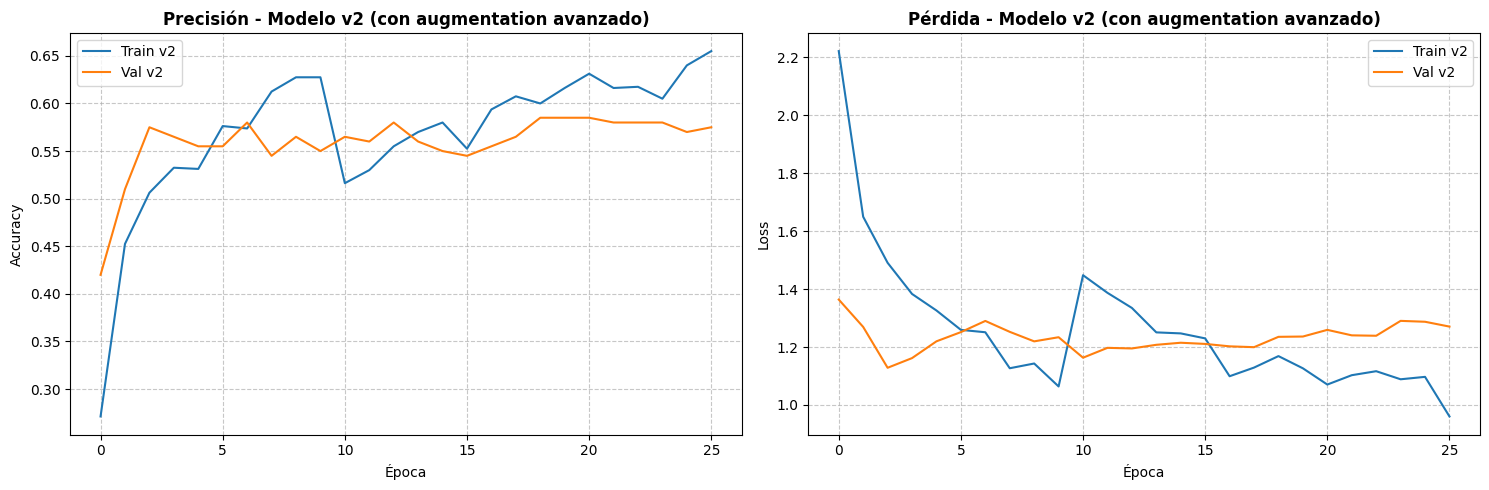

In [ ]:
# entrenar modelo nuevo
print("=" * 60)
print("-- MODELO V2: RESNET50V2 + AUGMENTATION AVANZADO --")
print("=" * 60)

# generador base (igual que el original)
train_datagen_v2 = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    validation_split=0.2,
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    zoom_range=0.1,
    brightness_range=[0.85, 1.15],
    fill_mode='nearest'
)

base_train_gen_v2 = train_datagen_v2.flow_from_directory(
    dataset_path,
    target_size=(512, 512),
    batch_size=8,
    class_mode='categorical',
    subset='training',
    shuffle=True,
    seed=42
)

# envolver con cutmix + mixup + cutout
train_gen_v2 = AugmentedGenerator(
    base_generator=base_train_gen_v2
)

# modelo nuevo (misma arquitectura, pesos frescos)
model_v2 = create_512_cnn_model()

callbacks_v2 = [
    EarlyStopping(
        monitor='val_loss',
        patience=10,
        restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=5,
        min_lr=1e-6,
        verbose=1
    ),
    ModelCheckpoint(
        'best_resnet_v2.h5',
        monitor='val_accuracy',
        save_best_only=True,
        verbose=1
    )
]

print("\nIniciando entrenamiento con augmentation avanzado...\n")

history_v2 = model_v2.fit(
    train_gen_v2,
    validation_data=val_gen,
    epochs=10,
    steps_per_epoch=len(train_gen_v2),
    callbacks=callbacks_v2,
    verbose=1
)

print("\n-- Fase 1 completada!")

# Continuar hasta 50 épocas si va bien
if history_v2.history['val_accuracy'][-1] > 0.25:
    print("\n-- Continuando con fine-tuning completo (hasta 50 épocas)...")

    history_v2_full = model_v2.fit(
        train_gen_v2,
        validation_data=val_gen,
        initial_epoch=len(history_v2.history['loss']),
        epochs=50,
        steps_per_epoch=len(train_gen_v2),
        callbacks=[
            EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True, verbose=1),
            ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=7, min_lr=1e-6, verbose=1),
            ModelCheckpoint('final_resnet_v2.h5', monitor='val_accuracy', save_best_only=True, verbose=1)
        ],
        verbose=1
    )

    for key in history_v2.history.keys():
        history_v2.history[key].extend(history_v2_full.history[key])

# Guardar modelo v2
model_v2.save('/content/drive/MyDrive/electivo/modelo_v2_augmentation.h5')
print("\nModelo v2 guardado en Drive.")

# Curvas de entrenamiento
plt.figure(figsize=(15, 5))
plt.subplot(1, 2, 1)
plt.plot(history_v2.history['accuracy'], label='Train v2')
plt.plot(history_v2.history['val_accuracy'], label='Val v2')
plt.title('Precisión - Modelo v2 (con augmentation avanzado)', fontweight='bold')
plt.xlabel('Época')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)

plt.subplot(1, 2, 2)
plt.plot(history_v2.history['loss'], label='Train v2')
plt.plot(history_v2.history['val_loss'], label='Val v2')
plt.title('Pérdida - Modelo v2 (con augmentation avanzado)', fontweight='bold')
plt.xlabel('Época')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

-- COMPARACIÓN: MODELO ORIGINAL vs MODELO V2 --

Modelo                           Accuracy       Loss
----------------------------------------------------
v1 (sin augmentation)               60.0%     1.1507
v2 (CutMix+MixUp+CutOut)            56.5%     1.1631

Diferencia de accuracy: -3.5%


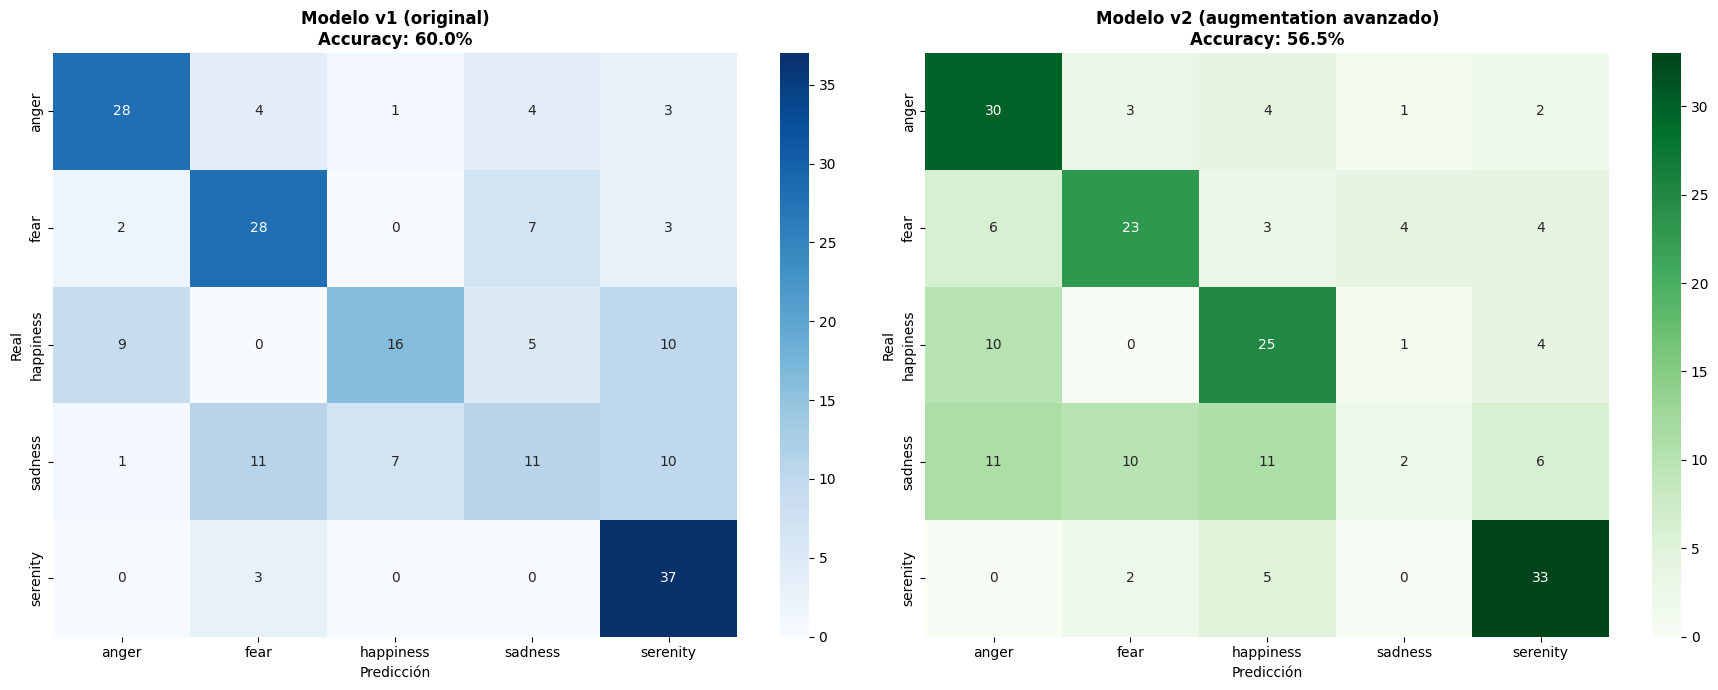


-- REPORTE MODELO V1 (original):
              precision    recall  f1-score   support

       anger       0.70      0.70      0.70        40
        fear       0.61      0.70      0.65        40
   happiness       0.67      0.40      0.50        40
     sadness       0.41      0.28      0.33        40
    serenity       0.59      0.93      0.72        40

    accuracy                           0.60       200
   macro avg       0.59      0.60      0.58       200
weighted avg       0.59      0.60      0.58       200


-- REPORTE MODELO V2 (augmentation avanzado):
              precision    recall  f1-score   support

       anger       0.53      0.75      0.62        40
        fear       0.61      0.57      0.59        40
   happiness       0.52      0.62      0.57        40
     sadness       0.25      0.05      0.08        40
    serenity       0.67      0.82      0.74        40

    accuracy                           0.56       200
   macro avg       0.52      0.57      0.52       

In [ ]:
# Comparación entre modelos

print("=" * 60)
print("-- COMPARACIÓN: MODELO ORIGINAL vs MODELO V2 --")
print("=" * 60)

class_names = list(val_gen.class_indices.keys())

# métricas modelo original (model_new)
val_gen.reset()
loss_v1, acc_v1 = model_new.evaluate(val_gen, verbose=0)
val_gen.reset()
preds_v1 = np.argmax(model_new.predict(val_gen, verbose=0), axis=1)
true_labels = val_gen.classes

# métricas modelo v2
val_gen.reset()
loss_v2, acc_v2 = model_v2.evaluate(val_gen, verbose=0)
val_gen.reset()
preds_v2 = np.argmax(model_v2.predict(val_gen, verbose=0), axis=1)

# resumen numérico
print(f"\n{'Modelo':<30} {'Accuracy':>10} {'Loss':>10}")
print("-" * 52)
print(f"{'v1 (sin augmentation)':<30} {acc_v1*100:>9.1f}% {loss_v1:>10.4f}")
print(f"{'v2 (CutMix+MixUp+CutOut)':<30} {acc_v2*100:>9.1f}% {loss_v2:>10.4f}")
mejora = (acc_v2 - acc_v1) * 100
signo = "+" if mejora >= 0 else ""
print(f"\nDiferencia de accuracy: {signo}{mejora:.1f}%")

# matrices de confusión lado a lado
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

cm_v1 = confusion_matrix(true_labels, preds_v1)
sns.heatmap(cm_v1, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names, ax=axes[0])
axes[0].set_title(f'Modelo v1 (original)\nAccuracy: {acc_v1*100:.1f}%',
                  fontweight='bold')
axes[0].set_xlabel('Predicción')
axes[0].set_ylabel('Real')

cm_v2 = confusion_matrix(true_labels, preds_v2)
sns.heatmap(cm_v2, annot=True, fmt='d', cmap='Greens',
            xticklabels=class_names, yticklabels=class_names, ax=axes[1])
axes[1].set_title(f'Modelo v2 (augmentation avanzado)\nAccuracy: {acc_v2*100:.1f}%',
                  fontweight='bold')
axes[1].set_xlabel('Predicción')
axes[1].set_ylabel('Real')

plt.tight_layout()
plt.show()

# reporte de clasificación comparado
print("\n-- REPORTE MODELO V1 (original):")
print(classification_report(true_labels, preds_v1, target_names=class_names))

print("\n-- REPORTE MODELO V2 (augmentation avanzado):")
print(classification_report(true_labels, preds_v2, target_names=class_names))

# Mejora v3: Fine-Tuning + Class Weights + Label Smoothing
Combinamos cuatro mejoras sobre el modelo v2:
1. Class Weights: penaliza más los errores en Sadness y Fear
2. Fine-Tuning real: descongelamos las últimas capas de ResNet
3. Label Smoothing: evita sobreconfianza en clases ambiguas
4. Augmentation más suave: solo CutOut (sin CutMix ni MixUp)

In [ ]:
import numpy as np # Ensure numpy is imported if not already

def cutout(image, n_holes, hole_size):
    img = image.copy()
    h, w, _ = img.shape
    for _ in range(n_holes):
        y = np.random.randint(h)
        x = np.random.randint(w)

        y1 = np.clip(y - hole_size // 2, 0, h)
        y2 = np.clip(y + hole_size // 2, 0, h)
        x1 = np.clip(x - hole_size // 2, 0, w)
        x2 = np.clip(x + hole_size // 2, 0, w)

        img[y1:y2, x1:x2] = 0 # Black out the region
    return img

# cutOut suave, sin cutmix ni mixup
class GeneradorCutOut(tf.keras.utils.Sequence):
    def __init__(self, base_generator, cutout_prob=0.5,
                 cutout_holes=2, cutout_size=70):
        self.gen = base_generator
        self.cutout_prob = cutout_prob
        self.cutout_holes = cutout_holes
        self.cutout_size = cutout_size

    def __len__(self):
        return len(self.gen)

    def __getitem__(self, idx):
        images, labels = self.gen[idx]
        for i in range(len(images)):
            if np.random.random() < self.cutout_prob:
                # Images are typically preprocessed to [-1, 1] or similar by preprocess_input
                # We need to convert them back to 0-255 range for image manipulation
                img_255 = ((images[i] + 1.0) * 127.5).clip(0, 255).astype(np.uint8)
                img_255 = cutout(img_255, n_holes=self.cutout_holes, hole_size=self.cutout_size)
                images[i] = preprocess_input(img_255.astype(np.float32)) # Re-apply preprocessing
        return images, labels

    def on_epoch_end(self):
        self.gen.on_epoch_end()

print("GeneradorCutOut definido.")

GeneradorCutOut definido.


In [ ]:
# calcular class weights automáticamente
from sklearn.utils.class_weight import compute_class_weight

# obtener etiquetas reales del generador
val_gen.reset()
y_train_labels = []

# reconstruir las etiquetas de entrenamiento desde el generador base
temp_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    validation_split=0.2
)
temp_gen = temp_datagen.flow_from_directory(
    dataset_path,
    target_size=(512, 512),
    batch_size=8,
    class_mode='categorical',
    subset='training',
    shuffle=False,
    seed=42
)
y_train_labels = temp_gen.classes
class_names_v3 = list(temp_gen.class_indices.keys())

# calcular pesos
class_weights_array = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train_labels),
    y=y_train_labels
)
class_weights = dict(enumerate(class_weights_array))

print("Class weights calculados:")
for i, (clase, peso) in enumerate(zip(class_names_v3, class_weights_array)):
    print(f"  {clase:<12} → peso {peso:.3f}")

print("\nInterpretación: peso > 1 = clase subrepresentada (modelo penaliza más sus errores)")

Found 800 images belonging to 5 classes.
Class weights calculados:
  anger        → peso 1.000
  fear         → peso 1.000
  happiness    → peso 1.000
  sadness      → peso 1.000
  serenity     → peso 1.000

Interpretación: peso > 1 = clase subrepresentada (modelo penaliza más sus errores)


In [ ]:
# fine-tuning y label smoothing
def create_model_v3():
    # cargar base ResNet50V2
    base_model = ResNet50V2(
        weights='imagenet',
        include_top=False,
        input_shape=(512, 512, 3)
    )

    # congelar todo primero
    base_model.trainable = False

    # descongelar solo las últimas 30 capas (capas residuales superiores)
    for layer in base_model.layers[-30:]:
        # no descongelar batchnormalization
        if not isinstance(layer, tf.keras.layers.BatchNormalization):
            layer.trainable = True

    capas_entrenables = sum(1 for l in base_model.layers if l.trainable)
    print(f"Capas entrenables en ResNet: {capas_entrenables} de {len(base_model.layers)}")

    # arquitectura de la cabeza
    model = models.Sequential([
        base_model,
        layers.GlobalAveragePooling2D(),
        layers.Dense(512, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.5),
        layers.Dense(256, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.4),
        layers.Dense(5, activation='softmax')
    ])

    # label smoothing = 0.1: en vez de [0,0,1,0,0] usamos [0.02,0.02,0.92,0.02,0.02]
    # reduce sobreconfianza en clases ambiguas como fear/anger
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=5e-5),
        loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.1),
        metrics=['accuracy']
    )

    return model

model_v3 = create_model_v3()
print("\nModelo v3 creado.")

Capas entrenables en ResNet: 22 de 190

Modelo v3 creado.


In [ ]:
# generador de entrenamiento v3
train_datagen_v3 = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    validation_split=0.2,
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    zoom_range=0.1,
    brightness_range=[0.85, 1.15],
    fill_mode='nearest'
)

base_train_gen_v3 = train_datagen_v3.flow_from_directory(
    dataset_path,
    target_size=(512, 512),
    batch_size=8,
    class_mode='categorical',
    subset='training',
    shuffle=True,
    seed=42
)

# solo cutout
train_gen_v3 = GeneradorCutOut(
    base_generator=base_train_gen_v3,
    cutout_prob=0.5,
    cutout_holes=2,
    cutout_size=70
)

print(f"Generador v3 listo — {base_train_gen_v3.samples} imágenes de entrenamiento")

Found 800 images belonging to 5 classes.
Generador v3 listo — 800 imágenes de entrenamiento


-- MODELO V3: FINE-TUNING + CLASS WEIGHTS + LABEL SMOOTHING --

Fase 1: entrenando solo la cabeza (capas ResNet congeladas)...


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 94s 806ms/step - accuracy: 0.2988 - loss: 2.2724 - val_accuracy: 0.4800 - val_loss: 1.3736 - learning_rate: 1.0000e-04
Epoch 2/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 75s 750ms/step - accuracy: 0.3750 - loss: 1.9968 - val_accuracy: 0.5550 - val_loss: 1.2983 - learning_rate: 1.0000e-04
Epoch 3/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 76s 763ms/step - accuracy: 0.4112 - loss: 1.9368 - val_accuracy: 0.5600 - val_loss: 1.3509 - learning_rate: 1.0000e-04
Epoch 4/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 83s 765ms/step - accuracy: 0.4825 - loss: 1.7368 - val_accuracy: 0.5800 - val_loss: 1.3609 - learning_rate: 1.0000e-04
Epoch 5/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 726ms/step - accuracy: 0.4906 - loss: 1.6220
Epoch 5: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-05.
100/100 ━━━━━━━━━━━━━━━━━━━━ 76s 763ms/step - accuracy: 0.4938 - loss: 1.6182 - val_accuracy: 0.5800 - val_loss: 1.3658 - learning_rate: 1.0000e-04
Epoch 6/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 76s 757ms/st


Epoch 8: finished saving model to best_resnet_v3.h5
100/100 ━━━━━━━━━━━━━━━━━━━━ 98s 819ms/step - accuracy: 0.3975 - loss: 1.9499 - val_accuracy: 0.4250 - val_loss: 1.6788 - learning_rate: 5.0000e-05
Epoch 9/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 728ms/step - accuracy: 0.4004 - loss: 1.7913
Epoch 9: val_accuracy improved from 0.42500 to 0.53000, saving model to best_resnet_v3.h5



Epoch 9: finished saving model to best_resnet_v3.h5
100/100 ━━━━━━━━━━━━━━━━━━━━ 78s 773ms/step - accuracy: 0.4087 - loss: 1.8700 - val_accuracy: 0.5300 - val_loss: 1.4329 - learning_rate: 5.0000e-05
Epoch 10/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 725ms/step - accuracy: 0.4185 - loss: 1.8381
Epoch 10: val_accuracy did not improve from 0.53000
100/100 ━━━━━━━━━━━━━━━━━━━━ 76s 760ms/step - accuracy: 0.4000 - loss: 1.9319 - val_accuracy: 0.3400 - val_loss: 5.3814 - learning_rate: 5.0000e-05
Epoch 11/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 728ms/step - accuracy: 0.3020 - loss: 2.0789
Epoch 11: val_accuracy did not improve from 0.53000
100/100 ━━━━━━━━━━━━━━━━━━━━ 78s 780ms/step - accuracy: 0.3363 - loss: 1.9937 - val_accuracy: 0.2750 - val_loss: 2.5632 - learning_rate: 5.0000e-05
Epoch 12/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 714ms/step - accuracy: 0.3286 - loss: 2.0535
Epoch 12: val_accuracy did not improve from 0.53000
100/100 ━━━━━━━━━━━━━━━━━━━━ 75s 750ms/step - accuracy: 0.3300 - loss: 2.0677 - 


Modelo v3 guardado en Drive.


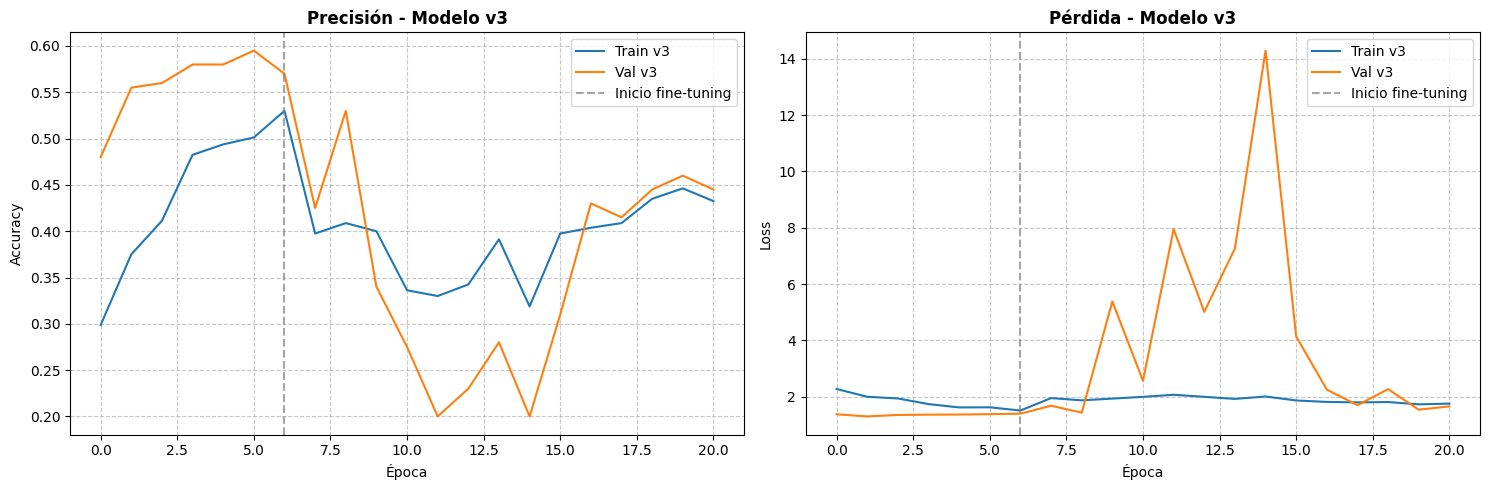

In [ ]:
# entrenamiento v3 (fase 1: cabeza, fase 2: fine-tuning)

print("=" * 60)
print("-- MODELO V3: FINE-TUNING + CLASS WEIGHTS + LABEL SMOOTHING --")
print("=" * 60)

# entrenar solo la cabeza (10 épocas)

# congelar ResNet completamente primero para estabilizar la cabeza
print("\nFase 1: entrenando solo la cabeza (capas ResNet congeladas)...")

for layer in model_v3.layers[0].layers:
    layer.trainable = False

model_v3.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.1),
    metrics=['accuracy']
)

history_v3_fase1 = model_v3.fit(
    train_gen_v3,
    validation_data=val_gen,
    epochs=10,
    steps_per_epoch=len(train_gen_v3),
    class_weight=class_weights,
    callbacks=[
        EarlyStopping(monitor='val_loss', patience=5,
                      restore_best_weights=True, verbose=1),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                          patience=3, min_lr=1e-6, verbose=1)
    ],
    verbose=1
)

# descongelar últimas 30 capas y fine-tuning
print("\nFase 2: fine-tuning con últimas 30 capas de ResNet descongeladas...")

for layer in model_v3.layers[0].layers[-30:]:
    if not isinstance(layer, tf.keras.layers.BatchNormalization):
        layer.trainable = True

# Learning rate más bajo para no destruir pesos preentrenados
model_v3.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=5e-5),
    loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.1),
    metrics=['accuracy']
)

history_v3_fase2 = model_v3.fit(
    train_gen_v3,
    validation_data=val_gen,
    initial_epoch=len(history_v3_fase1.history['loss']),
    epochs=50,
    steps_per_epoch=len(train_gen_v3),
    class_weight=class_weights,
    callbacks=[
        EarlyStopping(monitor='val_loss', patience=12,
                      restore_best_weights=True, verbose=1),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                          patience=6, min_lr=1e-7, verbose=1),
        ModelCheckpoint('best_resnet_v3.h5', monitor='val_accuracy',
                        save_best_only=True, verbose=1)
    ],
    verbose=1
)

# Unir historial de ambas fases
history_v3_completo = {}
for key in history_v3_fase1.history.keys():
    history_v3_completo[key] = (history_v3_fase1.history[key] +
                                 history_v3_fase2.history[key])

# Guardar
model_v3.save('/content/drive/MyDrive/electivo/modelo_v3_finetuning.h5')
print("\nModelo v3 guardado en Drive.")

# Curvas de entrenamiento
plt.figure(figsize=(15, 5))
plt.subplot(1, 2, 1)
plt.plot(history_v3_completo['accuracy'], label='Train v3')
plt.plot(history_v3_completo['val_accuracy'], label='Val v3')
# Línea vertical separando fase 1 y 2
plt.axvline(x=len(history_v3_fase1.history['loss']) - 1,
            color='gray', linestyle='--', alpha=0.7, label='Inicio fine-tuning')
plt.title('Precisión - Modelo v3', fontweight='bold')
plt.xlabel('Época')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)

plt.subplot(1, 2, 2)
plt.plot(history_v3_completo['loss'], label='Train v3')
plt.plot(history_v3_completo['val_loss'], label='Val v3')
plt.axvline(x=len(history_v3_fase1.history['loss']) - 1,
            color='gray', linestyle='--', alpha=0.7, label='Inicio fine-tuning')
plt.title('Pérdida - Modelo v3', fontweight='bold')
plt.xlabel('Época')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

-- COMPARACIÓN FINAL: V1 vs V2 vs V3 --

Modelo                                Accuracy       Loss
---------------------------------------------------------
v1 — ResNet original                     60.0%     1.1507
v2 — CutMix+MixUp+CutOut                 56.5%     1.1631
v3 — Fine-Tuning+ClassW+LabelSmooth      53.0%     1.4329

Mejor modelo: v1 con 60.0%


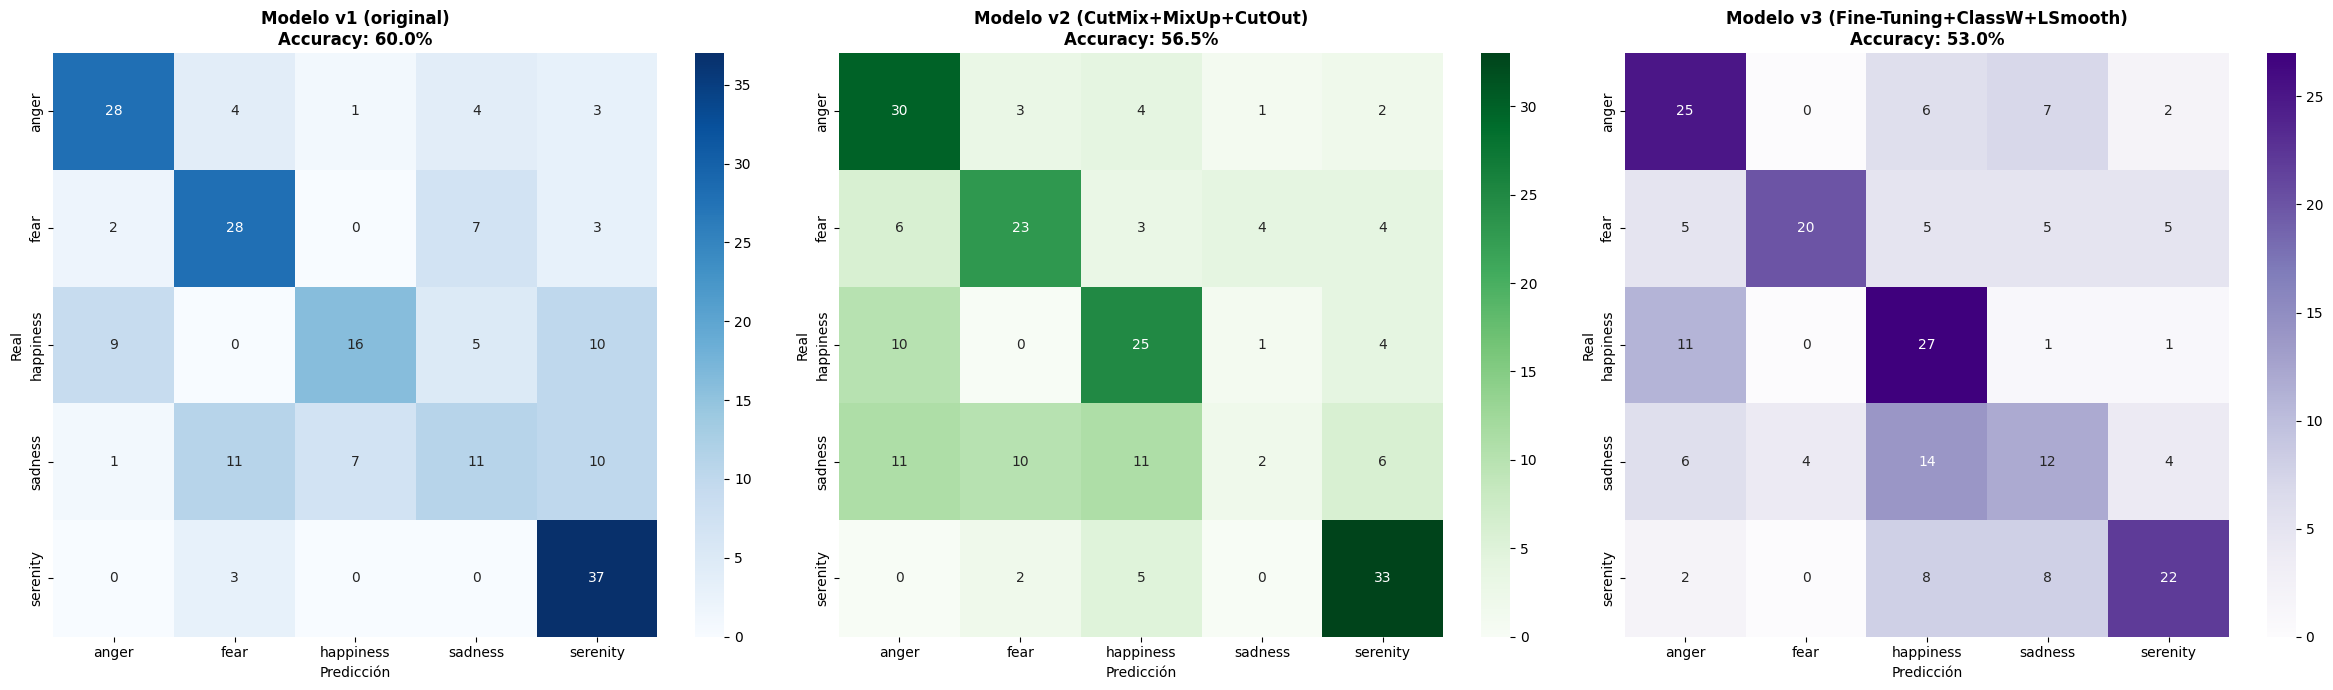


-- REPORTE DETALLADO MODELO V3:
              precision    recall  f1-score   support

       anger       0.51      0.62      0.56        40
        fear       0.83      0.50      0.62        40
   happiness       0.45      0.68      0.54        40
     sadness       0.36      0.30      0.33        40
    serenity       0.65      0.55      0.59        40

    accuracy                           0.53       200
   macro avg       0.56      0.53      0.53       200
weighted avg       0.56      0.53      0.53       200



In [ ]:
# comparación final v1 vs v2 vs v3

print("=" * 60)
print("-- COMPARACIÓN FINAL: V1 vs V2 vs V3 --")
print("=" * 60)

class_names_final = list(val_gen.class_indices.keys())

# Métricas v1
val_gen.reset()
loss_v1, acc_v1 = model_new.evaluate(val_gen, verbose=0)
val_gen.reset()
preds_v1 = np.argmax(model_new.predict(val_gen, verbose=0), axis=1)
true_labels = val_gen.classes

# Métricas v2
val_gen.reset()
loss_v2, acc_v2 = model_v2.evaluate(val_gen, verbose=0)
val_gen.reset()
preds_v2 = np.argmax(model_v2.predict(val_gen, verbose=0), axis=1)

# Métricas v3
val_gen.reset()
loss_v3, acc_v3 = model_v3.evaluate(val_gen, verbose=0)
val_gen.reset()
preds_v3 = np.argmax(model_v3.predict(val_gen, verbose=0), axis=1)

# Tabla resumen
print(f"\n{'Modelo':<35} {'Accuracy':>10} {'Loss':>10}")
print("-" * 57)
print(f"{'v1 — ResNet original':<35} {acc_v1*100:>9.1f}% {loss_v1:>10.4f}")
print(f"{'v2 — CutMix+MixUp+CutOut':<35} {acc_v2*100:>9.1f}% {loss_v2:>10.4f}")
print(f"{'v3 — Fine-Tuning+ClassW+LabelSmooth':<35} {acc_v3*100:>9.1f}% {loss_v3:>10.4f}")

mejor = max(acc_v1, acc_v2, acc_v3)
nombre_mejor = ['v1', 'v2', 'v3'][[acc_v1, acc_v2, acc_v3].index(mejor)]
print(f"\nMejor modelo: {nombre_mejor} con {mejor*100:.1f}%")

# Matrices de confusión — las 3 juntas
fig, axes = plt.subplots(1, 3, figsize=(24, 7))

for ax, preds, acc, titulo, cmap in zip(
    axes,
    [preds_v1, preds_v2, preds_v3],
    [acc_v1, acc_v2, acc_v3],
    ['v1 (original)', 'v2 (CutMix+MixUp+CutOut)', 'v3 (Fine-Tuning+ClassW+LSmooth)'],
    ['Blues', 'Greens', 'Purples']
):
    cm = confusion_matrix(true_labels, preds)
    sns.heatmap(cm, annot=True, fmt='d', cmap=cmap,
                xticklabels=class_names_final,
                yticklabels=class_names_final, ax=ax)
    ax.set_title(f'Modelo {titulo}\nAccuracy: {acc*100:.1f}%', fontweight='bold')
    ax.set_xlabel('Predicción')
    ax.set_ylabel('Real')

plt.tight_layout()
plt.show()

# Reporte por clase del mejor modelo
print(f"\n-- REPORTE DETALLADO MODELO V3:")
print(classification_report(true_labels, preds_v3, target_names=class_names_final))

In [ ]:
# funciones predict para v2 y v3
def predict_emotion_v2(img_path):
    img = Image.open(img_path).convert('RGB')
    img = img.resize((512, 512))
    img_array = np.array(img)
    img_array = preprocess_input(img_array)
    img_array = np.expand_dims(img_array, axis=0)
    predictions = model_v2.predict(img_array, verbose=0)
    class_names = ['anger', 'fear', 'happiness', 'sadness', 'serenity']
    predicted_idx = np.argmax(predictions[0])
    return class_names[predicted_idx], predictions[0][predicted_idx]


def predict_emotion_v3(img_path):
    img = Image.open(img_path).convert('RGB')
    img = img.resize((512, 512))
    img_array = np.array(img)
    img_array = preprocess_input(img_array)
    img_array = np.expand_dims(img_array, axis=0)
    predictions = model_v3.predict(img_array, verbose=0)
    class_names = ['anger', 'fear', 'happiness', 'sadness', 'serenity']
    predicted_idx = np.argmax(predictions[0])
    return class_names[predicted_idx], predictions[0][predicted_idx]


print("predict_emotion_v2() y predict_emotion_v3() listas.")

predict_emotion_v2() y predict_emotion_v3() listas.


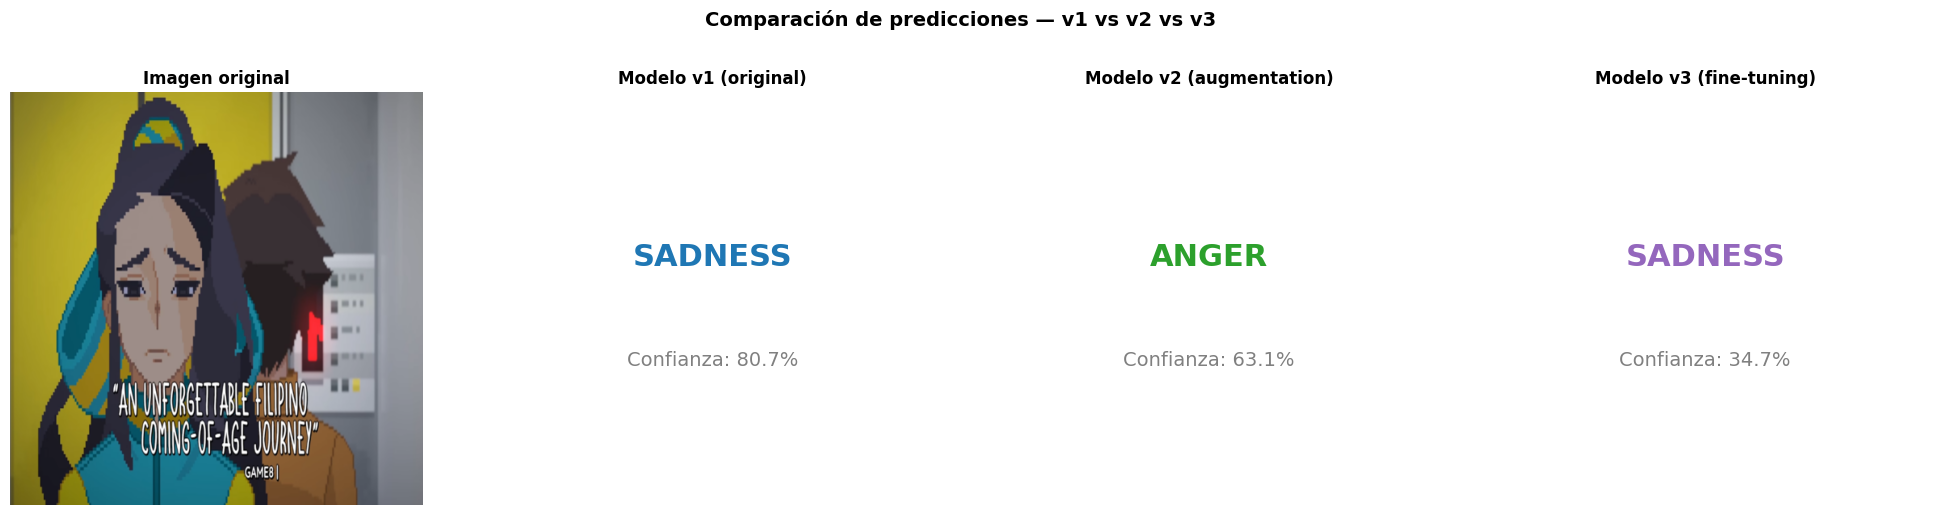

v1: sadness      (80.7%)
v2: anger        (63.1%)
v3: sadness      (34.7%)


In [ ]:
def comparar_predicciones(img_path):
    # probar los tres modelos con la misma imagen

    img = Image.open(img_path).convert('RGB')

    pred_v1, conf_v1 = predict_emotion_final(img_path)
    pred_v2, conf_v2 = predict_emotion_v2(img_path)
    pred_v3, conf_v3 = predict_emotion_v3(img_path)

    fig, axes = plt.subplots(1, 4, figsize=(20, 5))

    # Imagen original
    axes[0].imshow(img.resize((512, 512)))
    axes[0].set_title('Imagen original', fontweight='bold')
    axes[0].axis('off')

    # Resultado por modelo
    for ax, modelo, pred, conf, color in zip(
        axes[1:],
        ['v1 (original)', 'v2 (augmentation)', 'v3 (fine-tuning)'],
        [pred_v1, pred_v2, pred_v3],
        [conf_v1, conf_v2, conf_v3],
        ['#1f77b4', '#2ca02c', '#9467bd']
    ):
        ax.set_facecolor('#f8f8f8')
        ax.text(0.5, 0.6, pred.upper(),
                ha='center', va='center', fontsize=22,
                fontweight='bold', color=color,
                transform=ax.transAxes)
        ax.text(0.5, 0.35, f'Confianza: {conf:.1%}',
                ha='center', va='center', fontsize=14,
                color='gray', transform=ax.transAxes)
        ax.set_title(f'Modelo {modelo}', fontweight='bold')
        ax.axis('off')

    plt.suptitle('Comparación de predicciones — v1 vs v2 vs v3',
                 fontsize=14, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()

    print(f"v1: {pred_v1:<12} ({conf_v1:.1%})")
    print(f"v2: {pred_v2:<12} ({conf_v2:.1%})")
    print(f"v3: {pred_v3:<12} ({conf_v3:.1%})")

comparar_predicciones('/content/drive/MyDrive/electivo/games_mood/sadness/Until Then_sadness_1046.png')

# Mejora v4



In [ ]:
# Mejora v4: Ensamble con modelo pre-entrenado de detección facial + emoción (DeepFace)

!pip install deepface -q

from deepface import DeepFace
from sklearn.metrics import classification_report, confusion_matrix

# DeepFace devuelve: angry, disgust, fear, happy, sad, surprise, neutral
map_deepface_to_ours = {
    'angry': 'anger',
    'disgust': 'anger',
    'fear': 'fear',
    'happy': 'happiness',
    'sad': 'sadness',
    'neutral': 'serenity',
    'surprise': 'serenity'
}

def predict_deepface(img_path):
    try:
        result = DeepFace.analyze(img_path, actions=['emotion'],
                                   enforce_detection=False, silent=True)
        if isinstance(result, list):
            result = result[0]
        emo_scores = result['emotion']

        our_scores = {c: 0.0 for c in ['anger', 'fear', 'happiness', 'sadness', 'serenity']}
        for k, v in emo_scores.items():
            our_scores[map_deepface_to_ours[k]] += v

        total = sum(our_scores.values())
        if total == 0:
            return None
        return {k: v / total for k, v in our_scores.items()}
    except Exception:
        return None

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 170.7/170.7 kB 12.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 115.9/115.9 kB 12.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 212.0/212.0 kB 23.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 70.4/70.4 kB 7.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 79.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.3/51.3 kB 5.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 79.6 MB/s eta 0:00:00
26-07-13 12:32:22 - Directory /root/.deepface has been created
26-07-13 12:32:22 - Directory /root/.deepface/weights has been created


In [ ]:
class_names_v4 = list(val_gen.class_indices.keys())

def predict_ensemble(img_path, model=model_v3, w_cnn=0.6, w_face=0.4,
                      boost_classes=('fear', 'sadness'), boost_factor=1.3):
    # 1 Predicción de tu CNN (ResNet fine-tuned)
    img = Image.open(img_path).convert('RGB').resize((512, 512))
    arr = preprocess_input(np.array(img))
    arr = np.expand_dims(arr, axis=0)
    cnn_pred = model.predict(arr, verbose=0)[0]
    cnn_scores = {class_names_v4[i]: cnn_pred[i] for i in range(len(class_names_v4))}

    # 2 Predicción del modelo preentrenado de rostro
    face_scores = predict_deepface(img_path)

    if face_scores is None:
        final_scores = cnn_scores
    else:
        final_scores = {}
        for c in class_names_v4:
            score = w_cnn * cnn_scores[c] + w_face * face_scores[c]
            if c in boost_classes:
                score *= boost_factor
            final_scores[c] = score
        total = sum(final_scores.values())
        final_scores = {k: v / total for k, v in final_scores.items()}

    pred_class = max(final_scores, key=final_scores.get)
    return pred_class, final_scores

26-07-13 12:33:02 - 🔗 facial_expression_model_weights.h5 will be downloaded from https://github.com/serengil/deepface_models/releases/download/v1.0/facial_expression_model_weights.h5 to /root/.deepface/weights/facial_expression_model_weights.h5...


Downloading...
From: https://github.com/serengil/deepface_models/releases/download/v1.0/facial_expression_model_weights.h5
To: /root/.deepface/weights/facial_expression_model_weights.h5
100%|██████████| 5.98M/5.98M [00:00<00:00, 94.9MB/s]


              precision    recall  f1-score   support

       anger       0.38      0.38      0.38        21
        fear       0.22      0.25      0.23        20
   happiness       0.46      0.46      0.46        24
     sadness       0.27      0.35      0.30        20
    serenity       0.17      0.07      0.10        15

    accuracy                           0.32       100
   macro avg       0.30      0.30      0.29       100
weighted avg       0.31      0.32      0.31       100



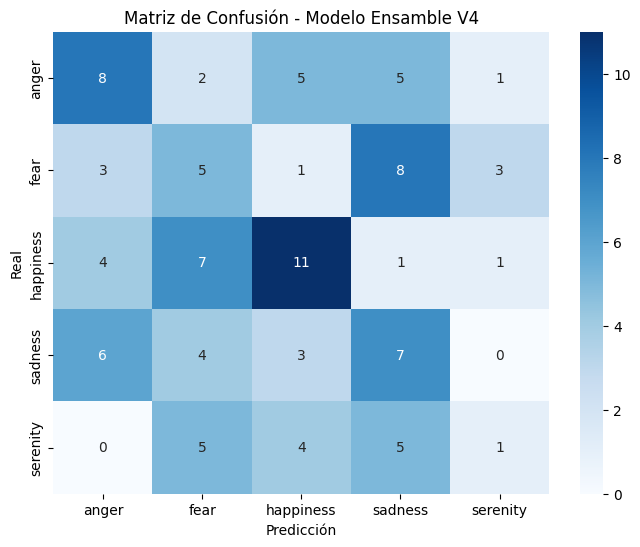

In [ ]:
def evaluate_ensemble(val_gen, model=model_v3, sample_size=None):
    val_gen.reset()
    filepaths = val_gen.filepaths
    y_true_idx = val_gen.classes
    idx_to_class = {v: k for k, v in val_gen.class_indices.items()}

    idxs = range(len(filepaths)) if sample_size is None else \
           random.sample(range(len(filepaths)), sample_size)

    y_true, y_pred = [], []
    for i in idxs:
        y_true.append(idx_to_class[y_true_idx[i]])
        pred_label, _ = predict_ensemble(filepaths[i], model=model)
        y_pred.append(pred_label)

    print(classification_report(y_true, y_pred))
    cm = confusion_matrix(y_true, y_pred, labels=class_names_v4)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', xticklabels=class_names_v4,
                yticklabels=class_names_v4, cmap='Blues')
    plt.title('Matriz de Confusión - Modelo Ensamble V4')
    plt.xlabel('Predicción')
    plt.ylabel('Real')
    plt.show()
    return y_true, y_pred

# empieza con una muestra (100) antes de correr todo el val set, DeepFace es lento
y_true_v4, y_pred_v4 = evaluate_ensemble(val_gen, model=model_v3, sample_size=100)

In [ ]:
# Este es para confirmar la hipótesis de ¿cuántas imágenes realmente "encontraron" un rostro válido?
def diagnosticar_deepface(val_gen, sample_size=100):
    val_gen.reset()
    filepaths = val_gen.filepaths
    idxs = random.sample(range(len(filepaths)), sample_size)

    detectados, no_detectados = 0, 0
    for i in idxs:
        scores = predict_deepface(filepaths[i])
        if scores is None:
            no_detectados += 1
        else:
            detectados += 1

    print(f"Rostro detectado: {detectados}/{sample_size}")
    print(f"Sin detección (fallback a CNN solo): {no_detectados}/{sample_size}")

diagnosticar_deepface(val_gen, sample_size=100)

Rostro detectado: 100/100
Sin detección (fallback a CNN solo): 0/100


In [ ]:
# Comparación directa: CNN sola vs Ensamble, sobre las mismas imágenes
#CNN = "Convolutional Neural Network",
def comparar_cnn_vs_ensemble(val_gen, model=model_v3, sample_size=100):
    val_gen.reset()
    filepaths = val_gen.filepaths
    y_true_idx = val_gen.classes
    idx_to_class = {v: k for k, v in val_gen.class_indices.items()}
    idxs = random.sample(range(len(filepaths)), sample_size)

    y_true, y_pred_cnn, y_pred_ens = [], [], []
    for i in idxs:
        path = filepaths[i]
        y_true.append(idx_to_class[y_true_idx[i]])

        img = Image.open(path).convert('RGB').resize((512, 512))
        arr = preprocess_input(np.array(img))
        arr = np.expand_dims(arr, axis=0)
        cnn_pred = model.predict(arr, verbose=0)[0]
        y_pred_cnn.append(class_names_v4[np.argmax(cnn_pred)])

        pred_label, _ = predict_ensemble(path, model=model)
        y_pred_ens.append(pred_label)

    print("--- SOLO CNN (v3) ---")
    print(classification_report(y_true, y_pred_cnn))
    print("--- ENSAMBLE (v4) ---")
    print(classification_report(y_true, y_pred_ens))

comparar_cnn_vs_ensemble(val_gen, model=model_v3, sample_size=100)

--- SOLO CNN (v3) ---
              precision    recall  f1-score   support

       anger       0.42      0.48      0.45        23
        fear       0.75      0.50      0.60        18
   happiness       0.43      0.65      0.52        20
     sadness       0.33      0.24      0.28        25
    serenity       0.57      0.57      0.57        14

    accuracy                           0.47       100
   macro avg       0.50      0.49      0.48       100
weighted avg       0.48      0.47      0.47       100

--- ENSAMBLE (v4) ---
              precision    recall  f1-score   support

       anger       0.39      0.30      0.34        23
        fear       0.29      0.22      0.25        18
   happiness       0.58      0.55      0.56        20
     sadness       0.31      0.44      0.36        25
    serenity       0.54      0.50      0.52        14

    accuracy                           0.40       100
   macro avg       0.42      0.40      0.41       100
weighted avg       0.41      0.40

# Este enfoque no es viable
Concluimos que usar un modelo preentrenado para detección de rostros no funciona con este dataset, ya que games_mood contiene escenas y personajes de videojuegos, no fotos de caras humanas reales. Por lo tanto, ningún detector entrenado con rostros reales tendrá un buen rendimiento aquí.

In [ ]:
device = "cpu"

clip_model = CLIPModel.from_pretrained(
    "openai/clip-vit-base-patch32"
)

clip_processor = CLIPProcessor.from_pretrained(
    "openai/clip-vit-base-patch32"
)

clip_model.eval()

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

CLIPModel(
  (text_model): CLIPTextModel(
    (embeddings): CLIPTextEmbeddings(
      (token_embedding): Embedding(49408, 512)
      (position_embedding): Embedding(77, 512)
    )
    (encoder): CLIPEncoder(
      (layers): ModuleList(
        (0-11): 12 x CLIPEncoderLayer(
          (self_attn): CLIPAttention(
            (k_proj): Linear(in_features=512, out_features=512, bias=True)
            (v_proj): Linear(in_features=512, out_features=512, bias=True)
            (q_proj): Linear(in_features=512, out_features=512, bias=True)
            (out_proj): Linear(in_features=512, out_features=512, bias=True)
          )
          (layer_norm1): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
          (mlp): CLIPMLP(
            (activation_fn): QuickGELUActivation()
            (fc1): Linear(in_features=512, out_features=2048, bias=True)
            (fc2): Linear(in_features=2048, out_features=512, bias=True)
          )
          (layer_norm2): LayerNorm((512,), eps=1e-05, eleme

In [ ]:
inputs = clip_processor(
    images=pil_image,
    return_tensors="pt"
)

x = clip_model.get_image_features(**inputs)

print(type(x))
print(x)

<class 'transformers.modeling_outputs.BaseModelOutputWithPooling'>
BaseModelOutputWithPooling(last_hidden_state=tensor([[[-0.0384,  0.3189, -0.1210,  ...,  0.2179,  0.1998, -0.1396],
         [-0.3287,  0.2248,  0.0358,  ...,  0.5817,  0.6400,  0.2381],
         [-0.1683,  0.5296,  0.2840,  ...,  0.1676,  0.2981,  0.2861],
         ...,
         [ 0.2269, -0.1409, -0.0500,  ...,  0.3432,  0.2315, -0.5450],
         [ 0.0976,  0.2036,  0.2668,  ...,  0.4682,  0.6644, -0.3020],
         [ 0.1341,  0.2871, -0.0841,  ...,  0.5359,  0.7013,  0.0484]]],
       grad_fn=<AddBackward0>), pooler_output=tensor([[-5.0022e-01,  2.9082e-01, -4.2167e-01,  4.4774e-03,  3.7560e-01,
         -7.1971e-01,  1.9574e-01, -4.2353e-01,  4.6922e-01,  2.1343e-01,
          3.6665e-01, -5.0070e-03,  7.1381e-01,  3.8772e-02,  3.2731e-01,
         -1.9009e-01, -5.7411e-02,  6.6607e-02, -1.3650e-01, -3.7892e-01,
          1.5179e-01,  1.9187e-01, -1.9615e-01, -8.1216e-01, -3.6881e-01,
          4.5358e-01, -4.7349e